# Análise quantitativa com os microdados do ENEM 2023 — notebook da aula

**Curso:** Métodos Quantitativos / Tópicos de Análise Quantitativa (CAEO/CAO — CBMDF)
**Autor:** André T. Campos

Este notebook é a **parte prática** do curso. Ele segue o percurso usado em turmas anteriores (conhecer a base → descrever → limpar → comparar grupos → testar → relacionar variáveis), agora com duas mudanças:

1. **Amostragem e tamanho do efeito no centro.** A base do ENEM tem *todos* os participantes. Isso permite algo que nunca acontece no trabalho real: conhecer o valor verdadeiro e verificar se a amostra, o intervalo de confiança e o teste acertam. Toda decisão de tamanho de amostra passa a ter justificativa, e todo teste vem acompanhado de **efeito + IC + tamanho do efeito**.
2. **IA integrada.** Em cada parte aparecem os **prompts dos slides** (caixas *IA*) e, logo depois, o código da **verificação independente** que o analista faz sobre a resposta da IA.

| Parte | Módulo (arquivo de conteúdo) | O que se faz |
|---|---|---|
| 0 | Módulo 0 — evidências e protocolo de IA | preparar o ambiente, ler a base, registrar |
| 1 | Módulos 1 e 2 — descritiva e EDA | conhecer a base, nulos, zeros, definir a base de análise |
| 2 | Módulo 3 — probabilidade e distribuições | normal, TCL, taxa de base, binomial |
| 3 | Módulo 4 — amostragem e IC | erro amostral, cobertura do IC, tamanho de amostra, planos, vieses |
| 4 | Módulo 5 — testes de hipóteses | pré-registro, poder, valor-p × tamanho do efeito, t, ANOVA, qui-quadrado |
| 5 | Módulo 6 — correlação e regressão | dispersão, regressão, resíduos, treino/teste, IDHM (falácia ecológica) |

**Fonte dos dados:** INEP, Microdados do ENEM 2023 — <https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem>. Usamos uma versão reduzida (25 colunas, todos os 3.933.955 inscritos, sem o número de inscrição), gerada por `src/gerar_base_aula.py`. **Consulte o dicionário de dados antes de usar qualquer coluna.**

**Reprodutibilidade:** toda sorteio usa a semente `2023`. Rodando de cima para baixo, os números saem iguais aos dos slides.

---
# Parte 0 — Preparação (Módulo 0)

O protocolo de IA do curso tem 7 regras: (1) pergunta e hipótese antes dos dados; (2) não enviar dados sensíveis; (3) pedir código, não números; (4) contexto completo no prompt; (5) pedir premissas e limitações; (6) verificar de forma independente; (7) registrar tudo. Este notebook aplica as regras 3, 6 e 7 em cada parte.

In [1]:
# Bibliotecas (todas disponíveis no Google Colab)
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

# Semente única do curso (regra 7: registrar a semente)
SEMENTE = 2023
rng = np.random.default_rng(SEMENTE)

In [2]:
# Estilo dos gráficos: títulos que dizem a conclusão, eixos rotulados, sem 3D, paleta fixa
AZUL, LARANJA, VERDE, CINZA, VERMELHO = '#2a78d6', '#eb6834', '#1baf7a', '#8a8984', '#e34948'
mpl.rcParams.update({
    'figure.figsize': (9, 5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 11, 'legend.frameon': False,
    'axes.prop_cycle': mpl.cycler(color=[AZUL, LARANJA, VERDE]),
})

# Pasta de saída (figuras para os slides). No Colab, é criada na pasta atual.
RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SAIDA = RAIZ / 'saida'
SAIDA.mkdir(exist_ok=True)

def salvar(fig, nome):
    # Salva a figura em saida/ para uso nos slides
    fig.savefig(SAIDA / f'{nome}.png', dpi=200, bbox_inches='tight')

def br(x, casas=1):
    # Formata número no padrão brasileiro: 1.234,5
    return f'{x:,.{casas}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

def fmt_p(p):
    return '< 0,001' if p < 0.001 else br(p, 3)

In [3]:
# Funções estatísticas usadas em todo o notebook (escritas à mão para que se veja a fórmula)

def ic_media(x, conf=0.95):
    # IC da média pela t de Student: média ± t * S/raiz(n)
    x = np.asarray(x, dtype=float)
    n, m = len(x), x.mean()
    ep = x.std(ddof=1) / np.sqrt(n)
    t = stats.t.ppf((1 + conf) / 2, n - 1)
    return m, m - t * ep, m + t * ep

def d_cohen(a, b):
    # d de Cohen: diferença de médias / desvio padrão combinado
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

def magnitude(d):
    # Convenções de Cohen (1988) — referência, não regra de decisão
    d = abs(d)
    return 'desprezível' if d < 0.2 else 'pequeno' if d < 0.5 else 'médio' if d < 0.8 else 'grande'

def comparar(a, b, nome_a='A', nome_b='B'):
    # Teste t de Welch + IC da diferença + d de Cohen: as três coisas que sempre se reportam
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    r = stats.ttest_ind(a, b, equal_var=False)
    ic = r.confidence_interval(0.95)
    d = d_cohen(a, b)
    return pd.Series({'grupo A': nome_a, 'grupo B': nome_b, 'n A': len(a), 'n B': len(b),
                      'média A': a.mean(), 'média B': b.mean(), 'diferença (A−B)': a.mean() - b.mean(),
                      'IC95% inf': ic.low, 'IC95% sup': ic.high, 't': r.statistic, 'p': r.pvalue,
                      'd de Cohen': d, 'magnitude': magnitude(d)})

def relatar(res, unidade='pontos'):
    # Frase-padrão de relatório: efeito + IC + p + tamanho do efeito
    print(f"{res['grupo A']} − {res['grupo B']}: diferença de {br(res['diferença (A−B)'])} {unidade} "
          f"(IC95% [{br(res['IC95% inf'])}; {br(res['IC95% sup'])}]); "
          f"d = {br(res['d de Cohen'], 2)} (efeito {res['magnitude']}); p {fmt_p(res['p'])}; "
          f"n = {br(res['n A'], 0)} e {br(res['n B'], 0)}.")

def classificar(lo, hi, margem):
    # Leitura de relevância: compara o IC95% da diferença com a margem de relevância fixada antes
    if lo > margem or hi < -margem:
        return 'diferença relevante'
    if -margem < lo and hi < margem:
        return 'diferente, mas irrelevante' if (lo > 0 or hi < 0) else 'equivalente na prática'
    if lo > 0 or hi < 0:
        return 'diferente; relevância incerta'
    return 'inconclusivo'

def eta2(y, grupos):
    # Eta ao quadrado: fração da variação total associada aos grupos (SQ entre / SQ total)
    df_ = pd.DataFrame({'y': np.asarray(y, dtype=float), 'g': np.asarray(grupos)})
    media = df_.y.mean()
    g = df_.groupby('g').y.agg(['count', 'mean'])
    sq_entre = (g['count'] * (g['mean'] - media) ** 2).sum()
    sq_total = ((df_.y - media) ** 2).sum()
    return sq_entre / sq_total

## 0.1 Leitura da base

**No Colab**, o notebook baixa a base da *Release* do repositório (`URL_BASE`). Localmente, lê o arquivo da pasta indicada na variável de ambiente `MQ_DADOS` ou, na falta dela, de `dados/` na raiz do projeto. O formato Parquet é colunar e comprimido: 55 MB em vez de 1,7 GB do CSV original, e a leitura leva segundos.

In [4]:
import os
ARQUIVO_LOCAL = Path(os.environ.get('MQ_DADOS', RAIZ / 'dados')) / 'enem2023_aula.parquet'
URL_BASE = 'https://github.com/atc857/metodos_quanti/releases/download/base-v1/enem2023_aula.parquet'

FONTE = ARQUIVO_LOCAL if ARQUIVO_LOCAL.exists() else URL_BASE
if not FONTE:
    raise FileNotFoundError('Defina URL_BASE com o link do arquivo enem2023_aula.parquet.')

insc = pd.read_parquet(FONTE)   # uma linha por INSCRITO
print(f'{len(insc):,} linhas × {insc.shape[1]} colunas'.replace(',', '.'))

3.933.955 linhas × 25 colunas


In [5]:
# Registro da execução (regra 7 do protocolo)
import sys, scipy, statsmodels, sklearn
print('Executado em:', datetime.now().strftime('%d/%m/%Y %H:%M'))
print('Python', sys.version.split()[0], '| pandas', pd.__version__, '| numpy', np.__version__,
      '| scipy', scipy.__version__, '| statsmodels', statsmodels.__version__, '| scikit-learn', sklearn.__version__)
print('Semente:', SEMENTE, '| Fonte:', 'arquivo local' if FONTE == ARQUIVO_LOCAL else URL_BASE)

Executado em: 03/10/2026 15:17
Python 3.14.7 | pandas 3.0.6 | numpy 2.5.3 | scipy 1.18.1 | statsmodels 0.15.0 | scikit-learn 1.9.1
Semente: 2023 | Fonte: arquivo local


## 0.2 Dicionário: os rótulos que vamos usar

Os códigos abaixo foram copiados do **Dicionário de Microdados do ENEM 2023** (planilha do INEP). Não deduza o significado de um código pelo nome da coluna: `TP_ESCOLA = 1` é "Não respondeu", e não "pública".

In [6]:
ROT_SEXO = {'F': 'Feminino', 'M': 'Masculino'}
ROT_COR = {0: 'Não declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda', 4: 'Amarela', 5: 'Indígena', 6: 'Não dispõe da informação'}
ROT_CONCLUSAO = {1: 'Já concluiu o EM', 2: 'Concluirá o EM em 2023', 3: 'Concluirá o EM após 2023', 4: 'Não concluiu e não está cursando'}
ROT_ESCOLA = {1: 'Não respondeu', 2: 'Pública', 3: 'Privada'}
ROT_DEPENDENCIA = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
ROT_PRESENCA = {0: 'Faltou', 1: 'Presente', 2: 'Eliminado'}
ROT_STATUS_RED = {1: 'Sem problemas', 2: 'Anulada', 3: 'Cópia do texto motivador', 4: 'Em branco', 6: 'Fuga ao tema',
                  7: 'Não atendimento ao tipo textual', 8: 'Texto insuficiente', 9: 'Parte desconectada'}
# Q001 (pai) e Q002 (mãe): até que série estudou
ROT_INSTRUCAO = {'A': 'Nunca estudou', 'B': 'Não completou o 5º ano', 'C': '5º ano, sem o 9º ano',
                 'D': '9º ano, sem o EM', 'E': 'EM, sem faculdade', 'F': 'Faculdade, sem pós',
                 'G': 'Pós-graduação', 'H': 'Não sei'}
# Q006: renda mensal da família (17 faixas ordinais, A a Q; salário mínimo de 2023 = R$ 1.320)
FAIXAS_RENDA = list('ABCDEFGHIJKLMNOPQ')
ROT_RENDA = {'A': 'Nenhuma renda', 'B': 'até 1.320', 'C': '1.320–1.980', 'D': '1.980–2.640', 'E': '2.640–3.300',
             'F': '3.300–3.960', 'G': '3.960–5.280', 'H': '5.280–6.600', 'I': '6.600–7.920', 'J': '7.920–9.240',
             'K': '9.240–10.560', 'L': '10.560–11.880', 'M': '11.880–13.200', 'N': '13.200–15.840',
             'O': '15.840–19.800', 'P': '19.800–26.400', 'Q': 'acima de 26.400'}
# Agrupamento em 4 faixas usado nos Módulos 4 e 5
RENDA_4 = {**dict.fromkeys('AB', '1) até R$ 1.320'), **dict.fromkeys('CDE', '2) R$ 1.320–3.300'),
           **dict.fromkeys('FGH', '3) R$ 3.300–6.600'), **dict.fromkeys('IJKLMNOPQ', '4) acima de R$ 6.600')}

AREAS = ['CN', 'CH', 'LC', 'MT']
NOTAS = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
NOME_NOTA = {'NU_NOTA_CN': 'Ciências da Natureza', 'NU_NOTA_CH': 'Ciências Humanas', 'NU_NOTA_LC': 'Linguagens',
             'NU_NOTA_MT': 'Matemática', 'NU_NOTA_REDACAO': 'Redação'}

### IA — Prompt do Módulo 0 (modelo de prompt de análise)

Este é o modelo de prompt do curso. A pergunta formulada aqui (federais × privadas em Linguagens) é a mesma que será **respondida na Parte 4**, com os dados.

```text
Papel: você é um estatístico revisando uma análise para gestores públicos.

Contexto: estou analisando os microdados do ENEM 2023 (uma linha por inscrito).
Colunas relevantes: NU_NOTA_LC (numérica, 0–1000, vazia se ausente),
TP_DEPENDENCIA_ADM_ESC (categórica: 1 federal, 2 estadual, 3 municipal, 4 privada;
preenchida só para concluintes de 2023), TP_PRESENCA_LC (1 = presente).

Pergunta: a nota média de Linguagens difere entre escolas federais e privadas?
Hipótese definida antes de ver os dados: H0 = médias iguais; alfa = 0,05; bilateral.
Diferença mínima relevante para a decisão: d = 0,2.

Tarefa: escreva código Python (pandas + scipy + statsmodels) que (1) filtre os presentes,
(2) calcule o tamanho de amostra para detectar d = 0,2 com poder de 80%,
(3) verifique as suposições do teste, (4) execute o teste,
(5) calcule o tamanho do efeito e o IC de 95% da diferença.

Restrições: não invente colunas; se algo for ambíguo, pergunte antes de supor;
comente cada passo em português; use semente aleatória fixa.

Formato da resposta: primeiro liste as suposições do teste e como verificá-las,
depois o código, depois como interpretar cada saída em linguagem de gestor.
```

**Verificação independente:** peça ao modelo para citar a linha do dicionário que justifica cada coluna usada e compare com a célula 0.2 acima.

---
# Parte 1 — Conhecer a base (Módulos 1 e 2)

> *"Antes de testar qualquer hipótese, conheça seus dados: de onde vêm, o que significa cada coluna, o que está faltando e o que está estranho."*

Roteiro de perfilamento (Módulo 2): origem → estrutura → valores ausentes → códigos → variáveis numéricas → relações → subpopulações.

## 1.1 Estrutura: uma linha = um inscrito

In [7]:
insc.head()

,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q005,Q006
0,14,M,1,1,1,0,NaN,NaN,5300108,Brasília,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,A,F,5,F
1,12,M,1,1,1,0,NaN,NaN,5300108,Brasília,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,F,E,3,H
2,6,F,1,1,1,0,NaN,NaN,4305108,Caxias do Sul,RS,1,1,1,1,502.0,498.9,475.6,363.2,1.0,700.0,H,E,5,C
3,2,F,3,2,2,0,CE,2.0,2304400,Fortaleza,CE,1,1,1,1,459.0,508.5,507.2,466.7,1.0,880.0,D,D,5,C
4,3,F,3,2,2,0,CE,2.0,2311306,Quixadá,CE,1,1,1,1,402.5,379.2,446.9,338.3,1.0,560.0,B,B,4,B


In [8]:
insc.tail()

,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q005,Q006
3933950,12,M,1,1,1,0,NaN,NaN,4303103,Cachoeirinha,RS,1,1,1,1,566.2,605.6,613.7,547.3,1.0,540.0,C,E,5,F
3933951,1,F,1,3,1,1,NaN,NaN,3550308,São Paulo,SP,1,1,1,1,377.2,535.6,610.6,644.4,1.0,640.0,F,F,4,F
3933952,3,F,3,2,2,0,NaN,NaN,4205407,Florianópolis,SC,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,C,6,B
3933953,2,M,1,2,3,0,NaN,NaN,3507605,Bragança Paulista,SP,1,1,1,1,515.7,539.0,536.0,569.0,1.0,600.0,G,G,3,N
3933954,3,F,3,2,2,0,SP,2.0,3534401,Osasco,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,F,4,C


In [9]:
print('Linhas × colunas:', insc.shape)
insc.dtypes.to_frame('tipo').T

Linhas × colunas: (3933955, 25)


,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q005,Q006
tipo,int64,str,int64,int64,int64,int64,str,float64,int64,str,str,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,str,str,int64,str


## 1.2 Quem são os inscritos

In [10]:
# Sexo e cor/raça, com rótulos do dicionário e em percentual
sexo = insc.TP_SEXO.map(ROT_SEXO).value_counts()
cor = insc.TP_COR_RACA.map(ROT_COR).value_counts()
display(pd.DataFrame({'n': sexo, '%': (100 * sexo / sexo.sum()).round(1)}))
display(pd.DataFrame({'n': cor, '%': (100 * cor / cor.sum()).round(1)}))

,n,%
TP_SEXO,,
Feminino,2411185,61.3
Masculino,1522770,38.7


,n,%
TP_COR_RACA,,
Parda,1706798,43.4
Branca,1575848,40.1
Preta,509511,13.0
Amarela,64512,1.6
Não declarado,52575,1.3
Indígena,24711,0.6


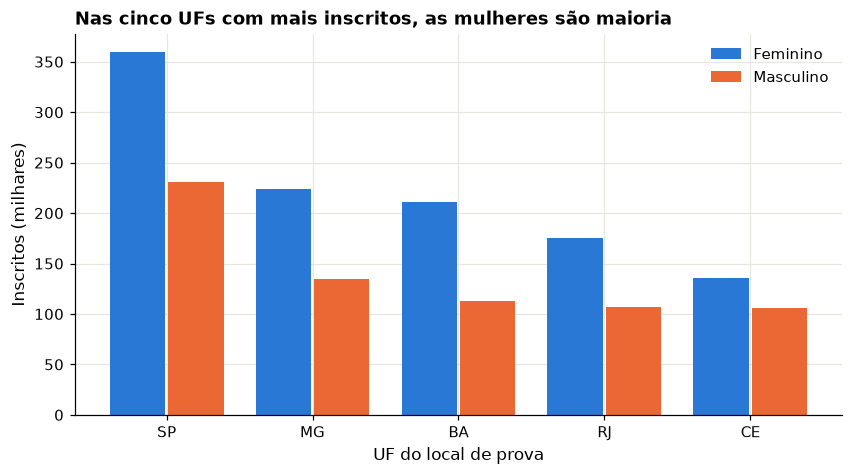

In [11]:
# As 5 UFs com mais inscritos (local de prova) e a divisão por sexo
top5 = insc.SG_UF_PROVA.value_counts().head(5)
tab = (insc[insc.SG_UF_PROVA.isin(top5.index)]
       .groupby(['SG_UF_PROVA', 'TP_SEXO']).size().unstack().loc[top5.index] / 1000)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(tab))
ax.bar(x - 0.2, tab['F'], width=0.38, label='Feminino', color=AZUL)
ax.bar(x + 0.2, tab['M'], width=0.38, label='Masculino', color=LARANJA)
ax.set_xticks(x, tab.index)
ax.set_ylabel('Inscritos (milhares)')
ax.set_xlabel('UF do local de prova')
ax.set_title('Nas cinco UFs com mais inscritos, as mulheres são maioria')
ax.legend()
plt.show()

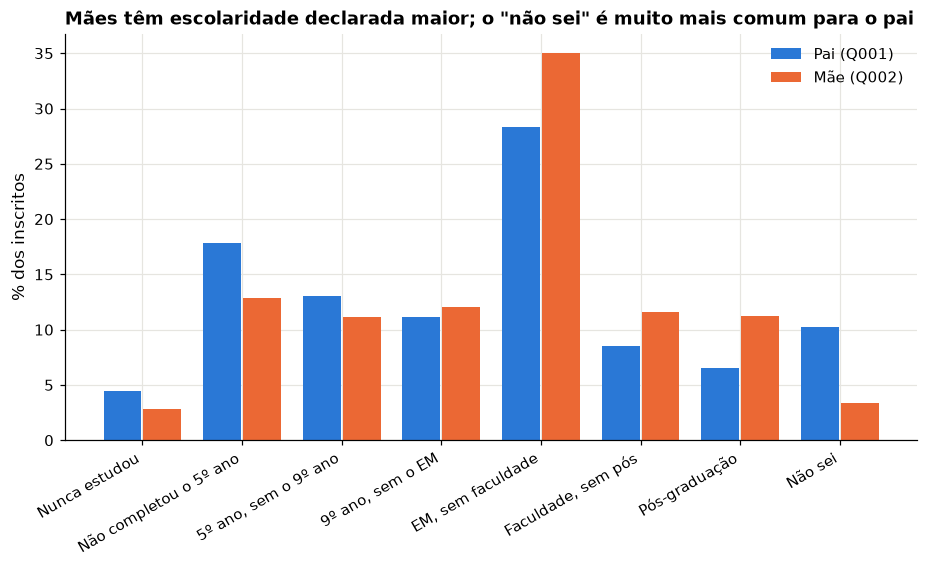

,Pai (Q001),Mãe (Q002)
A,4.4,2.8
B,17.8,12.9
C,13.0,11.1
D,11.1,12.0
E,28.3,35.0
F,8.5,11.6
G,6.5,11.2
H,10.3,3.4


In [12]:
# Escolaridade do pai (Q001) e da mãe (Q002), em % dos inscritos
instr = pd.DataFrame({'Pai (Q001)': insc.Q001.value_counts(normalize=True),
                      'Mãe (Q002)': insc.Q002.value_counts(normalize=True)}).loc[list('ABCDEFGH')] * 100
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(instr))
ax.bar(x - 0.2, instr['Pai (Q001)'], width=0.38, label='Pai (Q001)', color=AZUL)
ax.bar(x + 0.2, instr['Mãe (Q002)'], width=0.38, label='Mãe (Q002)', color=LARANJA)
ax.set_xticks(x, [ROT_INSTRUCAO[k] for k in instr.index], rotation=30, ha='right')
ax.set_ylabel('% dos inscritos')
ax.set_title('Mães têm escolaridade declarada maior; o "não sei" é muito mais comum para o pai')
ax.legend()
plt.show()
instr.round(1)

## 1.3 Valores ausentes: o nulo tem significado

Uma contagem de nulos sem pergunta não diz nada. A pergunta é: **por que** está faltando?

In [13]:
nulos = (insc.isna().mean() * 100).round(1).sort_values(ascending=False)
nulos[nulos > 0].to_frame('% nulos')

,% nulos
TP_DEPENDENCIA_ADM_ESC,75.6
SG_UF_ESC,75.6
NU_NOTA_CN,31.6
NU_NOTA_MT,31.6
NU_NOTA_LC,28.2
NU_NOTA_CH,28.2
NU_NOTA_REDACAO,28.2
TP_STATUS_REDACAO,28.2


In [14]:
# A nota de MT é nula exatamente para quem não esteve presente: o nulo É a ausência
pd.crosstab(insc.TP_PRESENCA_MT.map(ROT_PRESENCA), insc.NU_NOTA_MT.isna().map({True: 'nota vazia', False: 'nota preenchida'}))

NU_NOTA_MT,nota preenchida,nota vazia
TP_PRESENCA_MT,,
Eliminado,0,2212
Faltou,0,1239316
Presente,2692427,0


In [15]:
# A escola (dependência administrativa) só é informada por quem concluirá o EM em 2023
pd.crosstab(insc.TP_ST_CONCLUSAO.map(ROT_CONCLUSAO),
            insc.TP_DEPENDENCIA_ADM_ESC.isna().map({True: 'escola vazia', False: 'escola informada'}))

TP_DEPENDENCIA_ADM_ESC,escola informada,escola vazia
TP_ST_CONCLUSAO,,
Concluirá o EM após 2023,0,620067
Concluirá o EM em 2023,958506,442658
Já concluiu o EM,0,1895301
Não concluiu e não está cursando,0,17423


**Leitura:** comparar "federal × estadual × privada" com essa coluna analisa **apenas concluintes de 2023 que informaram a escola**, e não "os candidatos do ENEM". População-alvo × população acessível (Módulo 4).

## 1.4 Resumo descritivo das notas (presentes em cada prova)

In [16]:
# Para cada prova, só quem esteve presente naquela prova (redação: dia 1, junto com LC e CH)
linhas = {}
for nota in NOTAS:
    x = insc[nota].dropna()
    linhas[NOME_NOTA[nota]] = {'n': len(x), 'média': x.mean(), 'dp (n−1)': x.std(ddof=1),
                               'mín': x.min(), 'Q1': x.quantile(0.25), 'mediana': x.median(),
                               'Q3': x.quantile(0.75), 'máx': x.max()}
pd.DataFrame(linhas).T.round(1)

,n,média,dp (n−1),mín,Q1,mediana,Q3,máx
Ciências da Natureza,2692427.0,495.8,87.9,0.0,440.5,493.9,551.2,868.4
Ciências Humanas,2822643.0,523.4,88.6,0.0,467.8,530.4,584.9,823.0
Linguagens,2822643.0,518.1,75.5,0.0,471.4,523.1,570.3,820.8
Matemática,2692427.0,533.8,131.6,0.0,431.2,523.6,630.1,958.6
Redação,2822643.0,617.8,214.6,0.0,500.0,620.0,780.0,1000.0


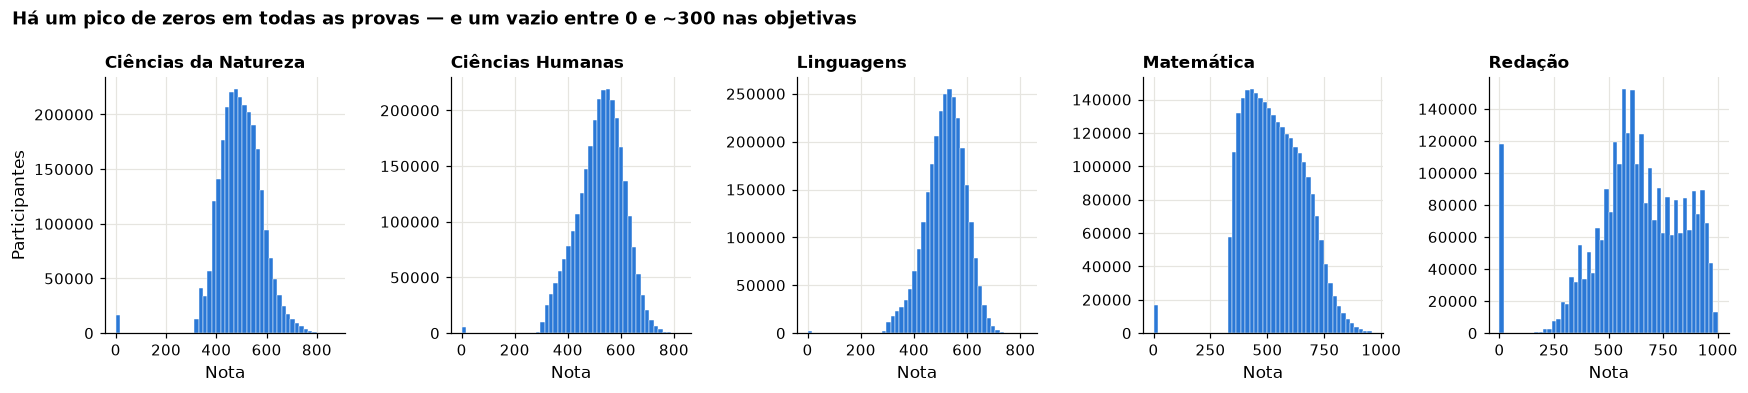

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=False)
for ax, nota in zip(axes, NOTAS):
    ax.hist(insc[nota].dropna(), bins=50, color=AZUL, edgecolor='white', linewidth=0.3)
    ax.set_title(NOME_NOTA[nota], fontsize=11)
    ax.set_xlabel('Nota')
axes[0].set_ylabel('Participantes')
fig.suptitle('Há um pico de zeros em todas as provas — e um vazio entre 0 e ~300 nas objetivas', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

## 1.5 Zeros: habilidade ou registro administrativo?

O histograma mostra zeros isolados. Antes de apagar, investigar.

In [18]:
for nota in NOTAS:
    x = insc[nota].dropna()
    print(f'{NOME_NOTA[nota]:22s} zeros: {br((x == 0).sum(), 0):>8s} | menor nota não nula: {br(x[x > 0].min())} | notas 1000: {br((x == 1000).sum(), 0)}')

Ciências da Natureza   zeros:   16.547 | menor nota não nula: 316,1 | notas 1000: 0
Ciências Humanas       zeros:    5.612 | menor nota não nula: 289,9 | notas 1000: 0
Linguagens             zeros:    2.169 | menor nota não nula: 287,0 | notas 1000: 0
Matemática             zeros:   16.638 | menor nota não nula: 319,8 | notas 1000: 0


Redação                zeros:  117.829 | menor nota não nula: 40,0 | notas 1000: 60


In [19]:
# Redação: o zero acompanha a situação da redação (TP_STATUS_REDACAO)
pd.crosstab(insc.TP_STATUS_REDACAO.map(ROT_STATUS_RED), insc.NU_NOTA_REDACAO == 0,
            colnames=['nota = 0']).sort_values(True, ascending=False)

nota = 0,False,True
TP_STATUS_REDACAO,,
Em branco,0,55403
Fuga ao tema,0,24466
Cópia do texto motivador,0,22505
Texto insuficiente,0,9091
Parte desconectada,0,2443
Anulada,0,2016
Não atendimento ao tipo textual,0,1905
Sem problemas,2704814,0


**O que os zeros são:**
- **Redação:** todo zero corresponde a `TP_STATUS_REDACAO ≠ 1` (anulada, em branco, fuga ao tema etc.). É **zero administrativo**, não medida de habilidade.
- **Provas objetivas:** não existe nota entre 0 e ~290 (a menor nota não nula de MT é 319,8). Conferindo no CSV completo do INEP (colunas `TX_RESPOSTAS_*`, que não estão na base reduzida), **todos os zeros das provas objetivas são cartões sem nenhuma resposta marcada** (16.638 em MT, 16.547 em CN, 5.612 em CH e 2.169 em LC): o participante esteve presente e entregou a prova em branco.

Nos dois casos, o zero **não mede desempenho**. Excluir esses casos é uma decisão justificada; apagar "toda linha com algum zero" sem saber por quê, não.

## 1.6 A base de análise (decisão registrada)

**Decisão:** para as análises de desempenho usaremos os participantes **presentes nas quatro provas objetivas**, com **redação sem problemas** (`TP_STATUS_REDACAO = 1`) e **nenhuma prova objetiva em branco** (nota 0). Os inscritos (`insc`) continuam disponíveis para as análises de presença (viés de seleção).

*Limitação a declarar:* quem faltou a um dos dias ou teve a redação anulada sai da base. Esses grupos não são aleatórios (Parte 3.7).

In [20]:
presente_4 = (insc[[f'TP_PRESENCA_{a}' for a in AREAS]] == 1).all(axis=1)
redacao_ok = insc.TP_STATUS_REDACAO == 1
em_branco = (insc[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT']] == 0).any(axis=1)

funil = pd.Series({
    'Inscritos': len(insc),
    'Presentes nas 4 provas objetivas': presente_4.sum(),
    '… e redação sem problemas': (presente_4 & redacao_ok).sum(),
    '… e nenhuma prova objetiva em branco (BASE)': (presente_4 & redacao_ok & ~em_branco).sum(),
})
base = insc[presente_4 & redacao_ok & ~em_branco].copy()
base['MEDIA_GERAL'] = base[NOTAS].mean(axis=1)
base['RENDA_4'] = base.Q006.map(RENDA_4)
display(funil.to_frame('participantes').assign(**{'% dos inscritos': (100 * funil / len(insc)).round(1)}))
print('Zeros restantes na base:', int((base[NOTAS] == 0).sum().sum()))

,participantes,% dos inscritos
Inscritos,3933955,100.0
Presentes nas 4 provas objetivas,2678264,68.1
… e redação sem problemas,2585115,65.7
… e nenhuma prova objetiva em branco (BASE),2569190,65.3


Zeros restantes na base: 0


## 1.7 Correlação entre as notas (exploração; volta na Parte 5)

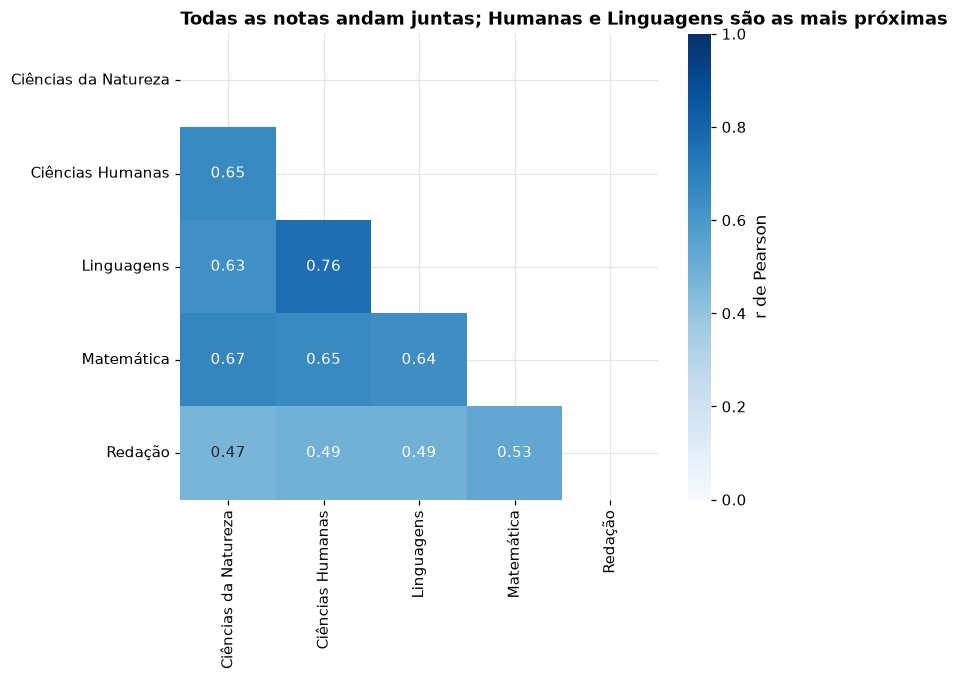

In [21]:
corr = base[NOTAS].rename(columns=NOME_NOTA).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', mask=mask, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'r de Pearson'})
ax.set_title('Todas as notas andam juntas; Humanas e Linguagens são as mais próximas')
plt.show()

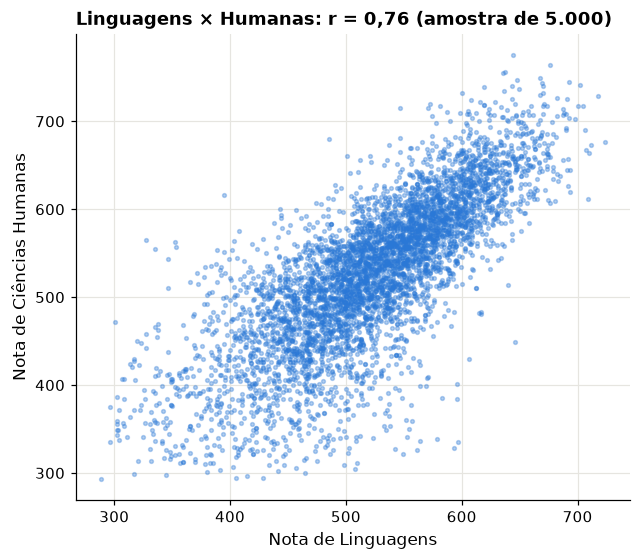

In [22]:
# Com 2,5 milhões de pontos, o gráfico de dispersão vira uma mancha: desenhar uma amostra
amostra_disp = base.sample(5000, random_state=SEMENTE)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(amostra_disp.NU_NOTA_LC, amostra_disp.NU_NOTA_CH, s=6, alpha=0.35, color=AZUL)
ax.set_xlabel('Nota de Linguagens')
ax.set_ylabel('Nota de Ciências Humanas')
ax.set_title(f"Linguagens × Humanas: r = {br(corr.loc['Linguagens', 'Ciências Humanas'], 2)} (amostra de 5.000)")
plt.show()

## 1.8 Comparação entre as regiões do Brasil

In [23]:
REGIAO = {'AC': 'Norte', 'AL': 'Nordeste', 'AP': 'Norte', 'AM': 'Norte', 'BA': 'Nordeste', 'CE': 'Nordeste',
          'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MT': 'Centro-Oeste',
          'MS': 'Centro-Oeste', 'MG': 'Sudeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PR': 'Sul', 'PE': 'Nordeste',
          'PI': 'Nordeste', 'RJ': 'Sudeste', 'RN': 'Nordeste', 'RS': 'Sul', 'RO': 'Norte', 'RR': 'Norte',
          'SC': 'Sul', 'SP': 'Sudeste', 'SE': 'Nordeste', 'TO': 'Norte'}
base['REGIAO'] = base.SG_UF_PROVA.map(REGIAO)
reg = base.groupby('REGIAO')[NOTAS].mean().rename(columns=NOME_NOTA)
reg.insert(0, 'n', base.REGIAO.value_counts())
reg.sort_values('Matemática', ascending=False).round(1)

,n,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
REGIAO,,,,,,
Sudeste,867248,517.4,548.7,540.2,571.6,666.1
Sul,278918,514.3,544.4,538.3,564.0,647.4
Centro-Oeste,210555,504.4,531.1,524.5,541.2,650.8
Nordeste,942924,487.4,514.5,509.3,518.2,644.7
Norte,269545,479.1,505.9,500.1,494.6,617.0


Média sozinha engana: a tabela agora mostra o **n** de cada grupo. Para dizer se uma diferença é "grande", faltam a **dispersão** (Módulo 1) e a **incerteza** (Módulo 4).

## 1.9 DF por dependência administrativa da escola

Em turmas anteriores comparamos três escolas do DF pelo código da escola. **Os microdados de 2023 não trazem `CO_ESCOLA`**, então a comparação passa a ser por dependência administrativa, com o tamanho de cada grupo e o intervalo de confiança.

In [24]:
df_dep = base[base.SG_UF_ESC == 'DF']
linhas = []
for cod, g in df_dep.groupby('TP_DEPENDENCIA_ADM_ESC'):
    m, lo, hi = ic_media(g.NU_NOTA_LC)
    linhas.append({'dependência': ROT_DEPENDENCIA[int(cod)], 'n': len(g), 'média LC': m, 'IC95% inf': lo, 'IC95% sup': hi,
                   'meia-largura do IC': (hi - lo) / 2})
pd.DataFrame(linhas).round(1)

,dependência,n,média LC,IC95% inf,IC95% sup,meia-largura do IC
0,Federal,788,558.3,553.8,562.8,4.5
1,Estadual,9145,520.3,519.0,521.6,1.3
2,Privada,6418,570.0,568.5,571.5,1.5


**Observe a última coluna:** o grupo menor tem o intervalo mais largo. Média de grupo pequeno varia mais, e é por isso que rankings de escolas ou de municípios **sem IC** enganam (Parte 3 e Parte 5.6).

## 1.10 Matemática por faixa de renda: a bivariada que prepara a ANOVA

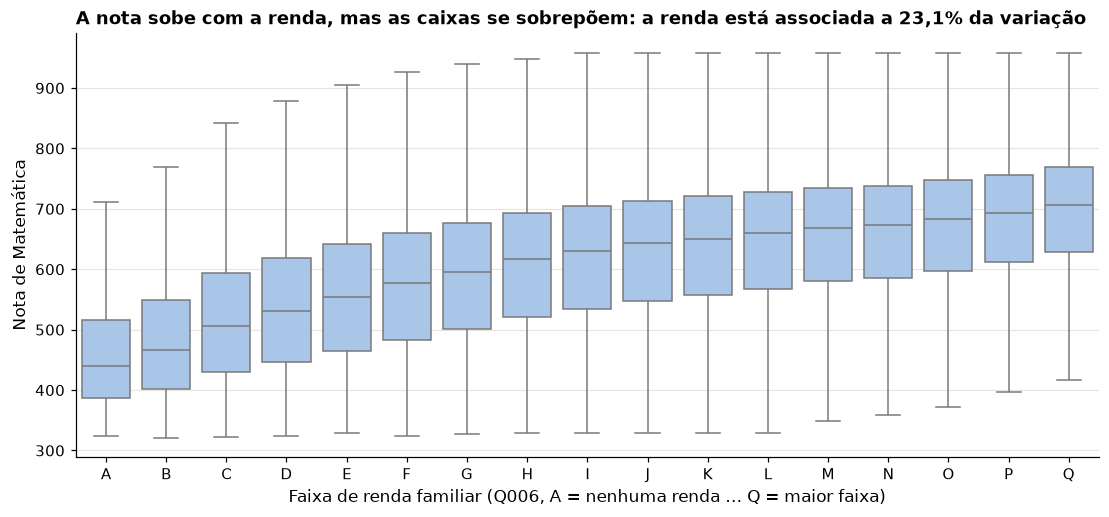

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=base, x='Q006', y='NU_NOTA_MT', order=FAIXAS_RENDA, showfliers=False,
            color='#9ec5f4', linewidth=1, ax=ax)
ax.set_xlabel('Faixa de renda familiar (Q006, A = nenhuma renda … Q = maior faixa)')
ax.set_ylabel('Nota de Matemática')
e2 = eta2(base.NU_NOTA_MT, base.Q006)
ax.set_title(f'A nota sobe com a renda, mas as caixas se sobrepõem: a renda está associada a {br(100 * e2)}% da variação')
salvar(fig, 'm2_mt_por_renda_boxplot')
plt.show()

**R² descritivo (BUS 4.6):** a fração da variação total de MT associada às 17 faixas de renda é o **η²** do título. O restante da variação ocorre **dentro** de cada faixa. É a semente da ANOVA (Parte 4) e da regressão (Parte 5).

### IA — Prompt 1 do Módulo 1 (resumo descritivo correto)

```text
Contexto: DataFrame pandas `df` com microdados do ENEM 2023, ~3,9 milhões de linhas.
Colunas: NU_NOTA_MT (float, vazia se ausente), TP_PRESENCA_MT (0 faltou, 1 presente,
2 eliminado), TP_ESCOLA (1 não respondeu, 2 pública, 3 privada).

Tarefa: escreva código que, para participantes presentes em MT, calcule por TP_ESCOLA:
n, média, mediana, desvio padrão AMOSTRAL, Q1, Q3, mínimo, máximo.

Requisitos:
- Declare explicitamente ddof e o método de cálculo dos quartis.
- Trate TP_ESCOLA==1 como categoria à parte e mostre quantos casos tem.
- Não use laços; use groupby.
- Ao final, liste em português 3 decisões de tratamento que você tomou e que eu devo confirmar.
```

In [26]:
# Verificação independente do código gerado pela IA
pres_mt = insc[insc.TP_PRESENCA_MT == 1]
resumo = (pres_mt.groupby(pres_mt.TP_ESCOLA.map(ROT_ESCOLA)).NU_NOTA_MT
          .agg(n='count', média='mean', mediana='median', dp=lambda s: s.std(ddof=1),
               Q1=lambda s: s.quantile(0.25, interpolation='linear'),
               Q3=lambda s: s.quantile(0.75, interpolation='linear'), mín='min', máx='max'))
display(resumo.round(1))

# (1) os n por grupo somam o total de presentes?
print('Soma dos n =', resumo.n.sum(), '| presentes em MT =', len(pres_mt), '| confere:', resumo.n.sum() == len(pres_mt))
# (2) ddof: pandas usa n−1 por padrão; numpy usa n. A diferença é pequena aqui, mas existe:
x = pres_mt.loc[pres_mt.TP_ESCOLA == 3, 'NU_NOTA_MT'].to_numpy()
print('dp privada  ddof=1:', round(x.std(ddof=1), 4), '| ddof=0:', round(x.std(ddof=0), 4))
# (3) uma linha recalculada sem groupby
print('média privada sem groupby:', round(x.mean(), 1))

,n,média,mediana,dp,Q1,Q3,mín,máx
TP_ESCOLA,,,,,,,,
Não respondeu,1637283,535.9,526.0,133.4,432.4,633.3,0.0,958.6
Privada,221705,630.8,646.7,124.6,548.6,718.8,0.0,958.6
Pública,833439,504.0,492.4,116.1,415.4,586.1,0.0,958.6


Soma dos n = 2692427 | presentes em MT = 2692427 | confere: True
dp privada  ddof=1: 124.6104 | ddof=0: 124.6101
média privada sem groupby: 630.8


### IA — Prompt 1 do Módulo 2 (perfilamento) e verificação

```text
Contexto: tenho um arquivo Parquet com os microdados do ENEM 2023 (3,9 milhões de linhas).
Vou colar abaixo o dicionário de dados das colunas que usarei (nome, descrição, categorias).
[colar o trecho do dicionário]

Tarefa: escreva um script Python que gere um relatório de qualidade de dados:
1) nº de linhas;
2) % de nulos por coluna;
3) para cada NU_NOTA_*, o cruzamento do nulo com TP_PRESENCA_* correspondente;
4) frequência de cada categoria de TP_ESCOLA e TP_DEPENDENCIA_ADM_ESC, com rótulos do dicionário;
5) contagem de notas iguais a zero e de máximos.

Regras: use apenas colunas que existem no dicionário que enviei; se precisar de outra coluna,
pergunte antes. Não interprete nem tire conclusões; apenas produza o código e os rótulos.
Comente cada bloco em português.
```

In [27]:
# Verificação: os números do relatório gerado pela IA devem bater com estes
print('Linhas (CSV oficial tem 3.933.955 linhas de dados):', len(insc))
for a in AREAS:
    nula = insc[f'NU_NOTA_{a}'].isna()
    ausente = insc[f'TP_PRESENCA_{a}'] != 1
    print(f'{a}: nota nula = não presente em todas as linhas? {bool((nula == ausente).all())}')
print(insc.TP_ESCOLA.map(ROT_ESCOLA).value_counts(normalize=True).mul(100).round(1).to_dict())

Linhas (CSV oficial tem 3.933.955 linhas de dados): 3933955
CN: nota nula = não presente em todas as linhas? True
CH: nota nula = não presente em todas as linhas? True
LC: nota nula = não presente em todas as linhas? True
MT: nota nula = não presente em todas as linhas? True
{'Não respondeu': 64.4, 'Pública': 29.7, 'Privada': 6.0}


### IA — Prompt 3 do Módulo 2 (hipóteses *antes* de olhar os dados)

```text
Quero escrever o plano de análise ANTES de ver os resultados.
Pergunta: [pergunta de gestão].
Variáveis: [variáveis e definições].
Gere um modelo de plano com: hipótese nula e alternativa, variável resposta, teste previsto,
nível de significância, critérios de exclusão de dados, comparações previstas (e quantas),
e como o resultado será reportado, inclusive se não for significativo.
Alerte para decisões que, se tomadas depois de ver os dados, inflariam falsos positivos.
```

**Hipóteses anotadas nesta aula** (serão testadas, com regras prévias, na Parte 4):
1. A nota de Linguagens difere entre escolas federais e privadas.
2. A média geral difere entre seis UFs (SP, MG, BA, RJ, RS, DF).
3. A escolaridade do pai está associada à faixa de renda familiar.

---
# Parte 2 — Probabilidade e distribuições (Módulo 3)

> *"Probabilidade responde: se o mundo fosse assim, o que eu veria? Inferência responde o inverso: vi isto, como é o mundo?"*

## 2.1 A normal descreve as notas?

In [28]:
# Regra 68-95-99,7: % de participantes a menos de 1, 2 e 3 desvios padrão da média
linhas = {}
for nota in NOTAS:
    x = base[nota].to_numpy()
    z = (x - x.mean()) / x.std()
    linhas[NOME_NOTA[nota]] = {'média': x.mean(), 'dp': x.std(), 'assimetria': stats.skew(x),
                               '|z|<1 (%)': 100 * (abs(z) < 1).mean(), '|z|<2 (%)': 100 * (abs(z) < 2).mean(),
                               '|z|<3 (%)': 100 * (abs(z) < 3).mean()}
print('Esperado na normal: 68,3% | 95,4% | 99,7%')
pd.DataFrame(linhas).T.round(2)

Esperado na normal: 68,3% | 95,4% | 99,7%


,média,dp,assimetria,|z|<1 (%),|z|<2 (%),|z|<3 (%)
Ciências da Natureza,500.93,78.77,0.35,68.21,95.39,99.57
Ciências Humanas,529.74,83.93,-0.26,67.82,95.18,99.97
Linguagens,523.17,72.26,-0.31,68.80,95.19,99.74
Matemática,540.60,124.91,0.37,62.51,97.39,99.88
Redação,649.81,174.88,-0.05,64.72,97.88,99.98


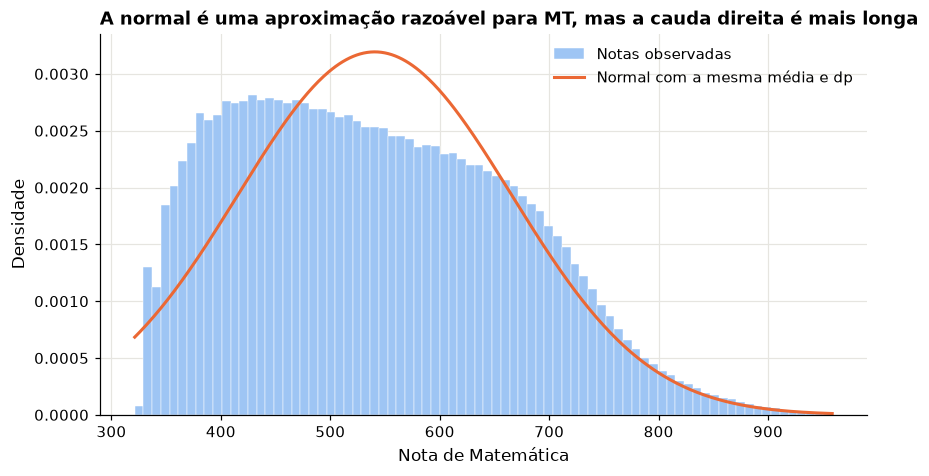

P(MT > 600): normal = 31,7% | observado = 32,7%
P(MT > 700): normal = 10,1% | observado = 12,0%
P(MT > 800): normal = 1,9% | observado = 2,2%
Percentis 1, 25, 50, 75, 95, 99: [336.5 436.9 529.4 634.2 754.2 838.7]


In [29]:
mt = base.NU_NOTA_MT.to_numpy()
MU, SIGMA = mt.mean(), mt.std()   # parâmetros da "população" do curso
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(mt, bins=80, density=True, color='#9ec5f4', edgecolor='white', linewidth=0.3, label='Notas observadas')
xs = np.linspace(mt.min(), mt.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA), color=LARANJA, lw=2, label='Normal com a mesma média e dp')
ax.set_xlabel('Nota de Matemática')
ax.set_ylabel('Densidade')
ax.set_title('A normal é uma aproximação razoável para MT, mas a cauda direita é mais longa')
ax.legend()
plt.show()

for lim in (600, 700, 800):
    print(f'P(MT > {lim}): normal = {br(100 * stats.norm.sf(lim, MU, SIGMA))}% | observado = {br(100 * (mt > lim).mean())}%')
print('Percentis 1, 25, 50, 75, 95, 99:', np.percentile(mt, [1, 25, 50, 75, 95, 99]).round(1))

## 2.2 Teorema Central do Limite com uma variável nada normal

A presença na prova é **binária** (0 ou 1). Mesmo assim, a **média de amostras** (a proporção de presentes) fica cada vez mais parecida com a normal, e menos dispersa, à medida que n cresce.

n =   5: dp das proporções = 0.2074 | teórico raiz(p(1−p)/n) = 0.2078
n =  30: dp das proporções = 0.0825 | teórico raiz(p(1−p)/n) = 0.0849
n = 400: dp das proporções = 0.0232 | teórico raiz(p(1−p)/n) = 0.0232


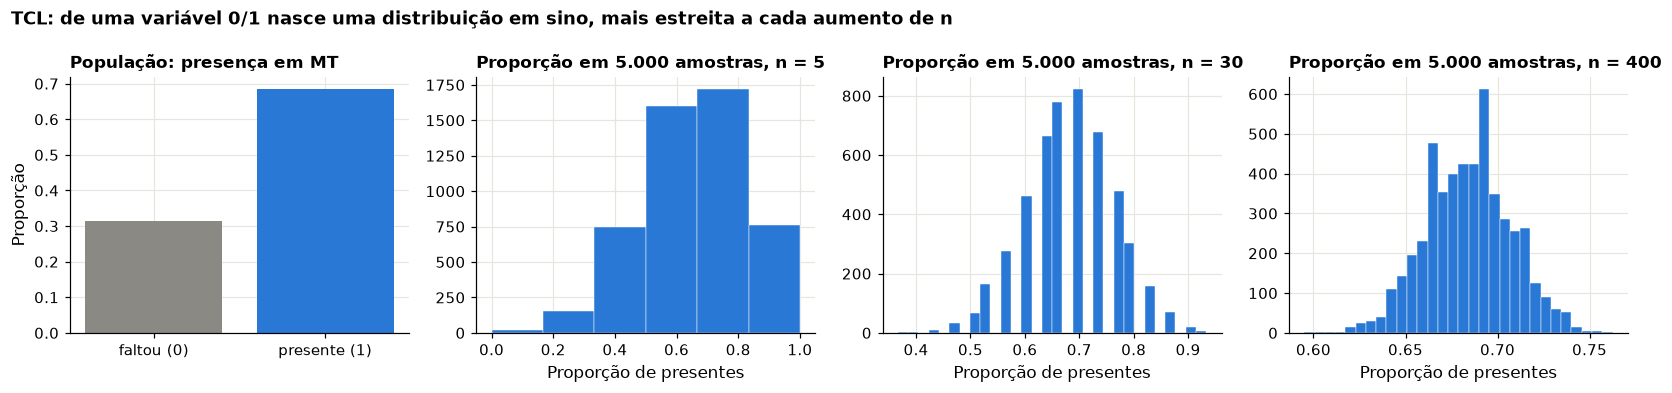

In [30]:
presenca = (insc.TP_PRESENCA_MT == 1).astype(int).to_numpy()
p_pop = presenca.mean()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
axes[0].bar(['faltou (0)', 'presente (1)'], [1 - p_pop, p_pop], color=[CINZA, AZUL])
axes[0].set_title('População: presença em MT', fontsize=11)
axes[0].set_ylabel('Proporção')
for ax, n in zip(axes[1:], (5, 30, 400)):
    medias = rng.choice(presenca, size=(5000, n)).mean(axis=1)
    ax.hist(medias, bins=30 if n > 5 else 6, color=AZUL, edgecolor='white', linewidth=0.3)
    ax.set_title(f'Proporção em 5.000 amostras, n = {n}', fontsize=11)
    ax.set_xlabel('Proporção de presentes')
    print(f'n = {n:3d}: dp das proporções = {medias.std(ddof=1):.4f} | teórico raiz(p(1−p)/n) = {np.sqrt(p_pop * (1 - p_pop) / n):.4f}')
fig.suptitle('TCL: de uma variável 0/1 nasce uma distribuição em sino, mais estreita a cada aumento de n', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm3_tcl_presenca')
plt.show()

## 2.3 Taxa de base: P(A|B) não é P(B|A)

In [31]:
rico = base.Q006.isin(list('KLMNOPQ'))       # renda acima de R$ 9.240
top = base.NU_NOTA_MT >= 700
print(f'P(renda K–Q) = {br(100 * rico.mean())}%   (taxa de base)')
print(f'P(MT ≥ 700) = {br(100 * top.mean())}%')
print(f'P(MT ≥ 700 | renda K–Q) = {br(100 * top[rico].mean())}%')
print(f'P(renda K–Q | MT ≥ 700) = {br(100 * rico[top].mean())}%')
pd.crosstab(rico.map({True: 'renda K–Q', False: 'demais faixas'}), top.map({True: 'MT ≥ 700', False: 'MT < 700'}), margins=True)

P(renda K–Q) = 9,7%   (taxa de base)
P(MT ≥ 700) = 12,0%
P(MT ≥ 700 | renda K–Q) = 41,0%
P(renda K–Q | MT ≥ 700) = 33,2%


NU_NOTA_MT,MT < 700,MT ≥ 700,All
Q006,,,
demais faixas,2114404,205611,2320015
renda K–Q,147072,102103,249175
All,2261476,307714,2569190


### IA — Prompts 1 e 2 do Módulo 3

```text
Problema: em um grupo de 12 militares escolhidos ao acaso de um batalhão grande, onde 35% têm
curso de especialização, quero a probabilidade de que pelo menos 6 tenham o curso.

Tarefa:
1) Diga qual distribuição de probabilidade modela X = nº com especialização e por quê.
2) LISTE as suposições necessárias e como cada uma poderia ser violada neste caso concreto.
3) Escreva código Python (scipy.stats) para calcular P(X >= 6) e também uma simulação Monte Carlo
   com 100.000 repetições e semente fixa.
4) Diga se os dois resultados devem coincidir e qual a margem esperada de diferença.
Não calcule "de cabeça": mostre o código e eu executarei.
```

```text
Afirmação de um relatório: "Como 40% dos alunos de alta renda tiram nota alta, 40% dos alunos
de nota alta são de alta renda."
Avalie a afirmação: (a) nomeie o erro de raciocínio, se houver, (b) escreva a probabilidade
condicional correta que a frase deveria estar descrevendo, (c) mostre com números hipotéticos
(tabela 2x2 com 10.000 pessoas) como as duas probabilidades podem diferir muito.
```

A verificação independente em probabilidade é a **simulação**: o cálculo exato e o Monte Carlo devem concordar.

In [32]:
# Verificação do Prompt 1: binomial exata × simulação
exato = stats.binom.sf(5, 12, 0.35)                 # P(X >= 6) = 1 − P(X <= 5)
simulado = (rng.binomial(12, 0.35, size=100_000) >= 6).mean()
print(f'P(X >= 6): exato = {exato:.4f} | simulado = {simulado:.4f} | margem esperada ≈ ±{2 * np.sqrt(exato * (1 - exato) / 100_000):.4f}')

# O mesmo raciocínio com o "chute" no ENEM: 45 itens, 5 alternativas
for k in (15, 18):
    print(f'Chute em 45 itens: P(acertos >= {k}) = {100 * stats.binom.sf(k - 1, 45, 0.2):.2f}% '
          f'(simulado: {100 * (rng.binomial(45, 0.2, 100_000) >= k).mean():.2f}%)')

P(X >= 6): exato = 0.2127 | simulado = 0.2107 | margem esperada ≈ ±0.0026
Chute em 45 itens: P(acertos >= 15) = 2.50% (simulado: 2.44%)
Chute em 45 itens: P(acertos >= 18) = 0.17% (simulado: 0.20%)


---
# Parte 3 — Amostragem e intervalos de confiança (Módulo 4)

**Por que amostrar, se temos todos?** No trabalho real (pesquisa de clima organizacional, auditoria de prontuários de ocorrências, avaliação de satisfação) quase sempre temos **só uma amostra**. Aqui fazemos o contrário: tratamos a base como **população**, conhecemos o valor verdadeiro e **sorteamos amostras** para ver como as estimativas se comportam. É um laboratório.

> *"Amostrar bem é decidir como o acaso entra no estudo. Com sorteio, é possível medir o erro; sem sorteio, o erro é desconhecido e quase sempre tem direção."*

## 3.1 Parâmetro, estimativa e erro amostral

In [33]:
print(f'População (base): N = {br(len(mt), 0)} participantes')
print(f'Parâmetro: média verdadeira de MT μ = {br(MU, 2)} | desvio padrão σ = {br(SIGMA, 2)}')

amostra = rng.choice(mt, size=400, replace=False)   # uma amostra aleatória simples (AAS)
m, lo, hi = ic_media(amostra)
print(f'\nUma AAS de n = 400: média = {br(m)} | S = {br(amostra.std(ddof=1))} | IC95% = [{br(lo)}; {br(hi)}]')
print(f'Erro amostral desta amostra = {br(m - MU)} pontos | o IC contém μ? {lo <= MU <= hi}')

População (base): N = 2.569.190 participantes
Parâmetro: média verdadeira de MT μ = 540,60 | desvio padrão σ = 124,91

Uma AAS de n = 400: média = 541,3 | S = 128,0 | IC95% = [528,7; 553,8]
Erro amostral desta amostra = 0,7 pontos | o IC contém μ? True


## 3.2 A distribuição das médias amostrais

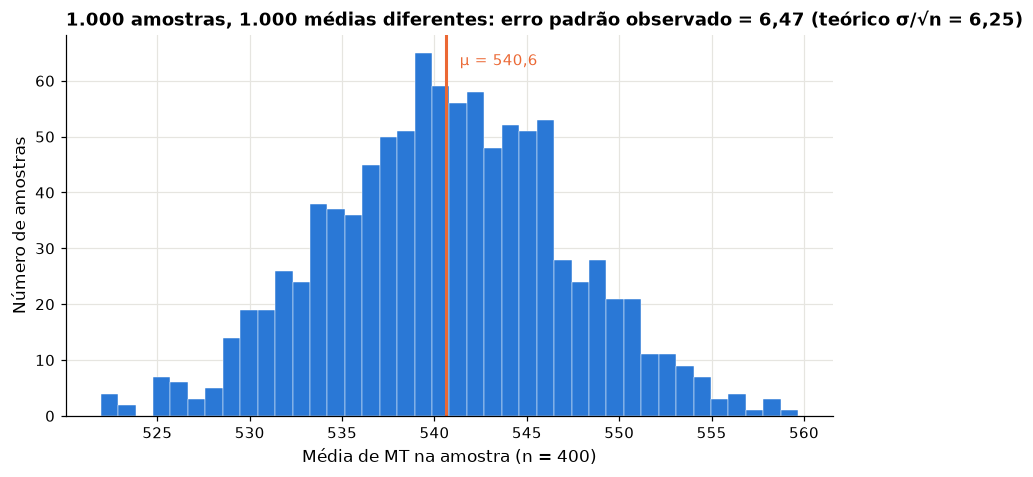

Erro padrão: observado = 6,47 | teórico σ/√n = 6,25; médias entre 521,9 e 559,7


In [34]:
# 1.000 amostras de n = 400 (com N de 2,5 milhões, sortear com ou sem reposição dá o mesmo)
medias_400 = rng.choice(mt, size=(1000, 400)).mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(medias_400, bins=40, color=AZUL, edgecolor='white', linewidth=0.3)
ax.axvline(MU, color=LARANJA, lw=2)
ax.text(MU + 0.5, ax.get_ylim()[1] * 0.92, f' μ = {br(MU)}', color=LARANJA)
ax.set_xlabel('Média de MT na amostra (n = 400)')
ax.set_ylabel('Número de amostras')
ax.set_title(f'1.000 amostras, 1.000 médias diferentes: erro padrão observado = {br(medias_400.std(ddof=1), 2)} (teórico σ/√n = {br(SIGMA / 20, 2)})')
salvar(fig, 'm4_distribuicao_medias')
plt.show()
print(f'Erro padrão: observado = {br(medias_400.std(ddof=1), 2)} | teórico σ/√n = {br(SIGMA / 20, 2)}; '
      f'médias entre {br(medias_400.min())} e {br(medias_400.max())}')

## 3.3 Como ler um intervalo de confiança

O parâmetro μ é fixo; **o intervalo é que varia**. "95% de confiança" quer dizer: se repetíssemos o procedimento muitas vezes, cerca de 95% dos intervalos conteriam μ.

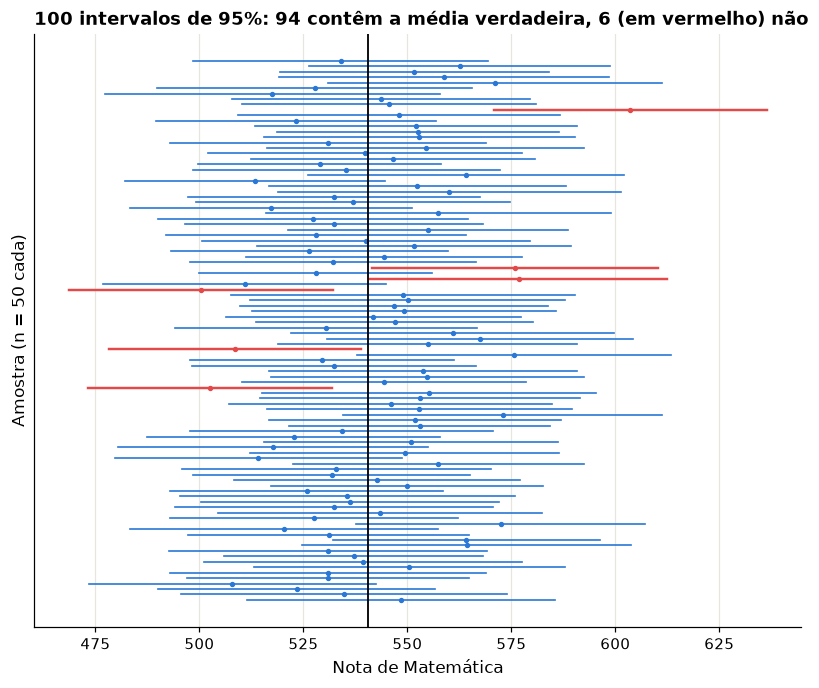

In [35]:
n = 50
amostras = rng.choice(mt, size=(100, n))
medias = amostras.mean(axis=1)
ep = amostras.std(axis=1, ddof=1) / np.sqrt(n)
t = stats.t.ppf(0.975, n - 1)
lo, hi = medias - t * ep, medias + t * ep
acertou = (lo <= MU) & (MU <= hi)

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(100):
    cor = AZUL if acertou[i] else VERMELHO
    ax.plot([lo[i], hi[i]], [i, i], color=cor, lw=1.6 if not acertou[i] else 1.1)
    ax.plot(medias[i], i, 'o', color=cor, ms=2.5)
ax.axvline(MU, color='black', lw=1.2)
ax.set_xlabel('Nota de Matemática')
ax.set_ylabel('Amostra (n = 50 cada)')
ax.set_yticks([])
ax.set_title(f'100 intervalos de 95%: {acertou.sum()} contêm a média verdadeira, {100 - acertou.sum()} (em vermelho) não')
salvar(fig, 'm4_cem_intervalos')
plt.show()

In [36]:
# Cobertura e largura do IC95% para vários n (1.000 amostras por n), com z e com t
linhas = []
for n in (10, 30, 100, 400, 1600):
    a = rng.choice(mt, size=(1000, n))
    med, ep = a.mean(axis=1), a.std(axis=1, ddof=1) / np.sqrt(n)
    tq = stats.t.ppf(0.975, n - 1)
    linhas.append({'n': n,
                   'cobertura z (%)': 100 * ((med - 1.96 * ep <= MU) & (MU <= med + 1.96 * ep)).mean(),
                   'cobertura t (%)': 100 * ((med - tq * ep <= MU) & (MU <= med + tq * ep)).mean(),
                   'largura média do IC t': (2 * tq * ep).mean()})
cobertura = pd.DataFrame(linhas).set_index('n')
cobertura.round(1)

,cobertura z (%),cobertura t (%),largura média do IC t
n,,,
10,90.4,93.8,176.2
30,93.9,94.3,93.1
100,95.8,95.8,49.4
400,95.5,95.5,24.5
1600,95.2,95.2,12.2


**Leitura:** (i) a cobertura fica perto de 95%, como prometido; com n pequeno, o IC pela **t** cobre melhor que o pela z; (ii) **quadruplicar n divide a largura por 2** (lei 1/√n).

## 3.4 Tamanho da amostra: quanto custa a precisão

Fórmulas (BAR 9.5): média, n = (z·σ/E)²; proporção, n = z²·π(1−π)/E². O erro tolerável **E** e a confiança são **decisões do gestor**, não do estatístico.

In [37]:
def n_media(sigma, E, conf=0.95):
    z = stats.norm.ppf((1 + conf) / 2)
    return int(np.ceil((z * sigma / E) ** 2))

def n_proporcao(E, p=0.5, conf=0.95, N=None):
    z = stats.norm.ppf((1 + conf) / 2)
    n0 = z ** 2 * p * (1 - p) / E ** 2
    if N is not None:                       # correção para população finita
        n0 = n0 / (1 + (n0 - 1) / N)
    return int(np.ceil(n0))

S_piloto = amostra.std(ddof=1)              # σ desconhecido: usar a amostra piloto da seção 3.1
for E in (10, 5):
    print(f'Média de MT com erro ±{E} pontos (95%): n = {n_media(S_piloto, E)}')
print('Proporção com erro ±3 p.p., pior caso π = 0,5: n =', n_proporcao(0.03))

# Verificação por simulação: com n para ±5 pontos, 95% das amostras erram menos de 5 pontos?
n5 = n_media(S_piloto, 5)
erros = np.abs(rng.choice(mt, size=(2000, n5)).mean(axis=1) - MU)
print(f'Com n = {n5}: {br(100 * (erros <= 5).mean())}% das 2.000 amostras erraram ≤ 5 pontos (esperado ≈ 95%)')

Média de MT com erro ±10 pontos (95%): n = 630
Média de MT com erro ±5 pontos (95%): n = 2519
Proporção com erro ±3 p.p., pior caso π = 0,5: n = 1068
Com n = 2519: 95,7% das 2.000 amostras erraram ≤ 5 pontos (esperado ≈ 95%)


## 3.5 O plano amostral muda a precisão (mesmo n)

Três planos, todos com **n = 400** e 1.000 repetições:
- **AAS:** sorteio simples de 400 participantes.
- **Estratificada proporcional por renda (4 faixas):** sorteio dentro de cada faixa, na proporção da faixa na população.
- **Conglomerados:** sorteio de 20 municípios de prova (com probabilidade proporcional ao tamanho) e 20 participantes em cada um. Mais barato em campo; menos preciso.

,média das estimativas,viés,erro padrão (dp das estimativas),n equivalente em AAS
AAS,540.88,0.28,6.37,384.44
Estratificada (renda),540.54,-0.06,5.61,495.92
Conglomerados (20×20),540.04,-0.56,10.82,133.30


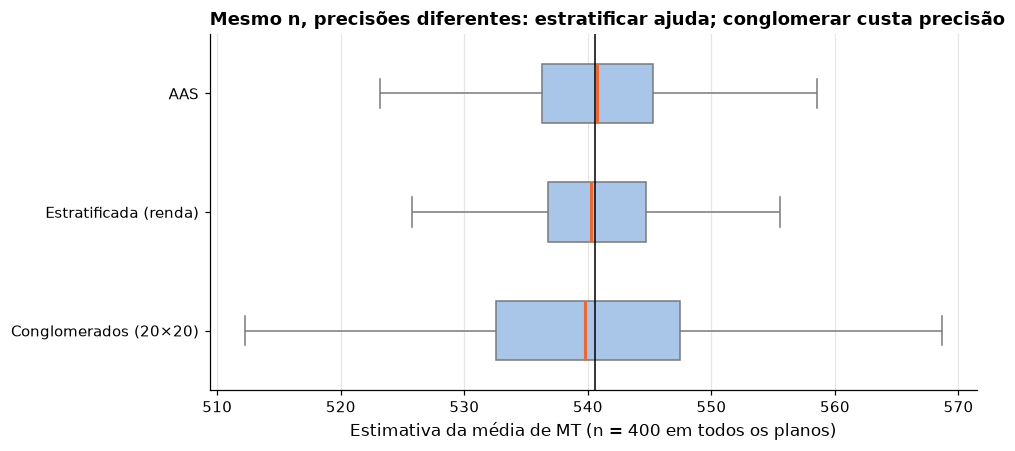

In [38]:
reps, n_total = 1000, 400

# AAS
est_aas = rng.choice(mt, size=(reps, n_total)).mean(axis=1)

# Estratificada proporcional
estratos = {k: base.loc[base.RENDA_4 == k, 'NU_NOTA_MT'].to_numpy() for k in sorted(base.RENDA_4.unique())}
pesos = {k: len(v) / len(mt) for k, v in estratos.items()}
alocacao = {k: round(n_total * w) for k, w in pesos.items()}
est_estr = sum(pesos[k] * rng.choice(v, size=(reps, alocacao[k])).mean(axis=1) for k, v in estratos.items())

# Conglomerados: municípios sorteados com probabilidade proporcional ao nº de participantes
mun = base.CO_MUNICIPIO_PROVA.to_numpy()
notas_por_mun = pd.Series(mt).groupby(mun).apply(np.asarray).to_dict()
est_cong = np.empty(reps)
for r in range(reps):
    sorteados = mun[rng.integers(0, len(mun), 20)]           # PPS: sortear 20 pessoas e usar o município de cada uma
    est_cong[r] = np.mean([rng.choice(notas_por_mun[c], 20).mean() for c in sorteados])

planos = pd.DataFrame({'AAS': est_aas, 'Estratificada (renda)': est_estr, 'Conglomerados (20×20)': est_cong})
resumo_planos = pd.DataFrame({'média das estimativas': planos.mean(), 'viés': planos.mean() - MU,
                              'erro padrão (dp das estimativas)': planos.std(ddof=1)})
resumo_planos['n equivalente em AAS'] = (SIGMA / resumo_planos['erro padrão (dp das estimativas)']) ** 2
display(resumo_planos.round(2))

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=planos.melt(var_name='plano', value_name='estimativa'), x='estimativa', y='plano', orient='h',
            color='#9ec5f4', width=0.5, showfliers=False, medianprops={'color': LARANJA, 'lw': 2}, ax=ax)
ax.set_ylabel('')
ax.axvline(MU, color='black', lw=1)
ax.set_xlabel('Estimativa da média de MT (n = 400 em todos os planos)')
ax.set_title('Mesmo n, precisões diferentes: estratificar ajuda; conglomerar custa precisão')
salvar(fig, 'm4_planos_amostrais')
plt.show()

**Leitura:** a estratificada é mais precisa porque a renda explica parte da variação (η² da seção 1.10): cada estrato é mais homogêneo. Nos conglomerados, alunos do mesmo município se parecem entre si; 400 alunos de 20 municípios valem bem menos que 400 alunos sorteados de todo o país (última coluna). Os três planos são **sem viés**: todos acertam na média.

## 3.6 Tamanho não cura viés: amostra de conveniência

Uma "pesquisa" que só ouve quem fez a prova no DF, por mais pessoas que entreviste, mira no alvo errado.

Média do DF = 561,8 (N = 48.592) | Brasil = 540,6 | viés = 21,2 pontos


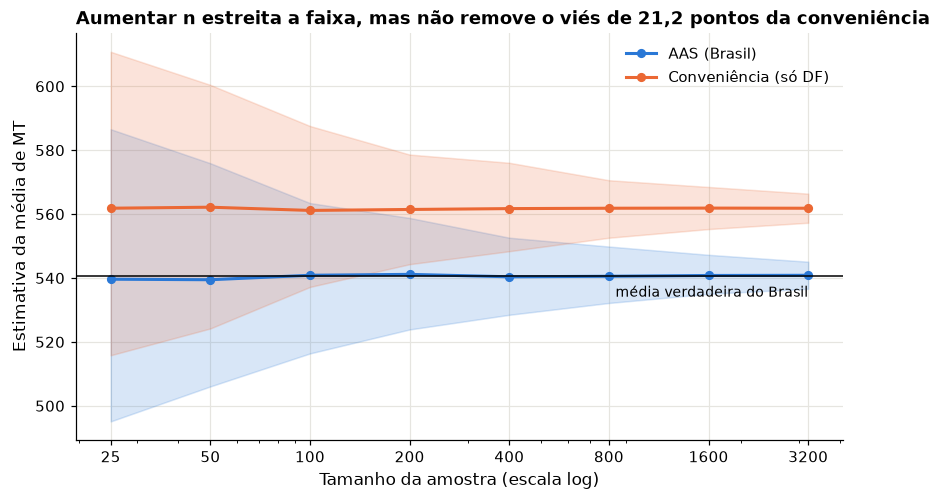

In [39]:
mt_df = base.loc[base.SG_UF_PROVA == 'DF', 'NU_NOTA_MT'].to_numpy()
ns = np.array([25, 50, 100, 200, 400, 800, 1600, 3200])
res = {'AAS (Brasil)': [], 'Conveniência (só DF)': []}
for n in ns:
    res['AAS (Brasil)'].append(rng.choice(mt, size=(500, n)).mean(axis=1))
    res['Conveniência (só DF)'].append(rng.choice(mt_df, size=(500, n)).mean(axis=1))

fig, ax = plt.subplots(figsize=(9, 4.8))
for (nome, ests), cor in zip(res.items(), (AZUL, LARANJA)):
    ests = np.array(ests)
    ax.fill_between(ns, np.percentile(ests, 2.5, axis=1), np.percentile(ests, 97.5, axis=1), color=cor, alpha=0.18)
    ax.plot(ns, ests.mean(axis=1), 'o-', color=cor, lw=2, ms=5, label=nome)
ax.axhline(MU, color='black', lw=1)
ax.text(ns[-1], MU - 3, 'média verdadeira do Brasil', ha='right', va='top', fontsize=9)
ax.set_xscale('log')
ax.set_xticks(ns, [str(v) for v in ns])
ax.set_xlabel('Tamanho da amostra (escala log)')
ax.set_ylabel('Estimativa da média de MT')
ax.set_title(f'Aumentar n estreita a faixa, mas não remove o viés de {br(mt_df.mean() - MU)} pontos da conveniência')
print(f'Média do DF = {br(mt_df.mean())} (N = {br(len(mt_df), 0)}) | Brasil = {br(MU)} | viés = {br(mt_df.mean() - MU)} pontos')
ax.legend(loc='upper right')
salvar(fig, 'm4_conveniencia_vies')
plt.show()

## 3.7 Viés de seleção: quem comparece à prova

A base de notas só tem **quem compareceu**. A presença depende da renda:

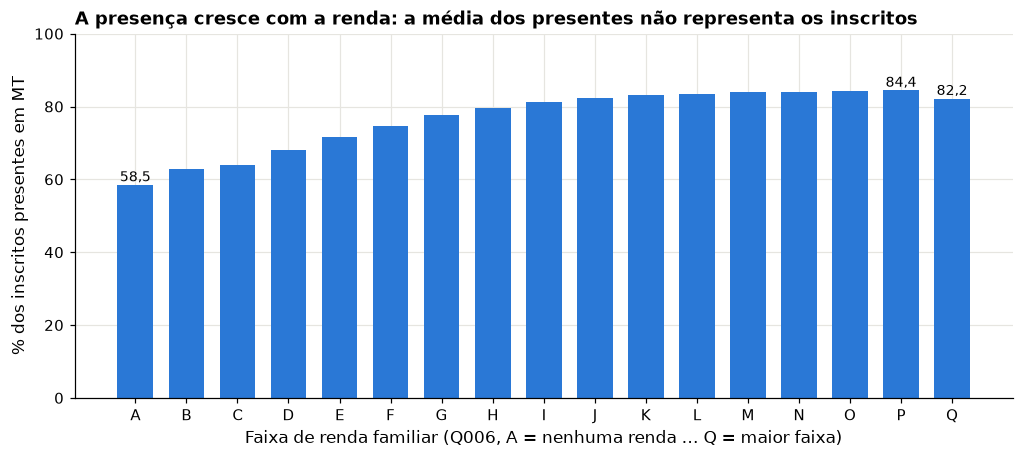

Q006,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q
% presentes,58.5,62.9,64.0,67.9,71.6,74.6,77.5,79.6,81.1,82.5,83.2,83.4,84.0,84.1,84.3,84.4,82.2


In [40]:
pres_renda = insc.groupby('Q006').TP_PRESENCA_MT.apply(lambda s: 100 * (s == 1).mean()).loc[FAIXAS_RENDA]
fig, ax = plt.subplots(figsize=(11, 4.3))
ax.bar(pres_renda.index, pres_renda.values, color=AZUL, width=0.7)
for i, v in enumerate(pres_renda.values):
    if i in (0, len(pres_renda) - 1) or i == int(np.argmax(pres_renda.values)):
        ax.text(i, v + 1, br(v), ha='center', fontsize=9)
ax.set_ylim(0, 100)
ax.set_xlabel('Faixa de renda familiar (Q006, A = nenhuma renda … Q = maior faixa)')
ax.set_ylabel('% dos inscritos presentes em MT')
ax.set_title('A presença cresce com a renda: a média dos presentes não representa os inscritos')
salvar(fig, 'm4_presenca_por_renda')
plt.show()
pres_renda.round(1).to_frame('% presentes').T

## 3.8 Paradoxo de Simpson: treineiros × demais

In [41]:
def faixa_etaria(c):
    return ('1) até 17 anos' if c <= 2 else '2) 18 anos' if c == 3 else '3) 19–20 anos' if c <= 5
            else '4) 21–25 anos' if c <= 10 else '5) 26 anos ou mais')
base['FAIXA_IDADE'] = base.TP_FAIXA_ETARIA.map(faixa_etaria)
treino = base.IN_TREINEIRO.map({0: 'Demais', 1: 'Treineiros'})

simpson = base.groupby(['FAIXA_IDADE', treino]).NU_NOTA_MT.mean().unstack()
simpson.loc['TOTAL'] = base.groupby(treino).NU_NOTA_MT.mean()
composicao = pd.crosstab(base.FAIXA_IDADE, treino, normalize='columns') * 100
display(simpson.round(1))
display(composicao.round(1).rename(columns=lambda c: f'% {c}'))

IN_TREINEIRO,Demais,Treineiros
FAIXA_IDADE,,
1) até 17 anos,556.3,552.4
2) 18 anos,540.7,493.6
3) 19–20 anos,540.0,471.1
4) 21–25 anos,537.8,432.7
5) 26 anos ou mais,506.3,422.4
TOTAL,538.5,549.4


IN_TREINEIRO,% Demais,% Treineiros
FAIXA_IDADE,,
1) até 17 anos,19.6,95.5
2) 18 anos,30.6,3.5
3) 19–20 anos,21.1,0.8
4) 21–25 anos,15.3,0.1
5) 26 anos ou mais,13.5,0.1


**Leitura:** no total, os treineiros têm média **maior**; em **cada** faixa etária, têm média **menor**. A composição etária (quase todos os treineiros têm até 17 anos, a faixa de maior média) inverte o sinal do agregado. É descrição de dados observacionais, não efeito causal de "ser treineiro".

## 3.9 Bootstrap: IC para a mediana (sem fórmula)

In [42]:
# A partir da MESMA amostra de n = 400 da seção 3.1
boot_med = np.array([np.median(rng.choice(amostra, 400)) for _ in range(5000)])
lo_b, hi_b = np.percentile(boot_med, [2.5, 97.5])
print(f'Mediana da amostra = {br(np.median(amostra))} | IC95% bootstrap (percentil) = [{br(lo_b)}; {br(hi_b)}] | '
      f'mediana verdadeira = {br(np.median(mt))}')

# Verificação independente: a função pronta do SciPy deve dar resultado parecido
r = stats.bootstrap((amostra,), np.median, n_resamples=5000, method='percentile', random_state=SEMENTE)
print(f'scipy.stats.bootstrap: [{br(r.confidence_interval.low)}; {br(r.confidence_interval.high)}]')

Mediana da amostra = 538,8 | IC95% bootstrap (percentil) = [516,1; 553,1] | mediana verdadeira = 529,4
scipy.stats.bootstrap: [516,1; 551,0]


### IA — Prompts do Módulo 4

**Prompt 1 — planejar a amostra e o tamanho**
```text
Preciso estimar, para um batalhão com 1.800 militares, a proporção que concorda com uma
mudança de escala. Quero 95% de confiança e margem de erro de ±4 pontos percentuais.
Há 5 companhias de tamanhos diferentes, e espero 25% de não resposta.

Tarefa:
1) Proponha um plano de amostragem (probabilístico) e justifique em relação a alternativas.
2) Calcule n com e sem correção para população finita; mostre a fórmula e o código Python.
3) Ajuste o n pela não resposta esperada.
4) Liste as 3 principais ameaças à validade (viés de cobertura, de não resposta, de medida)
   e como mitigar cada uma.
Se faltar alguma informação (variabilidade esperada, lista de elementos), pergunte antes.
```

**Prompt 2 — redigir a interpretação correta de um IC**
```text
A estimativa é 58% (n = 600), IC95% = [54,1%; 61,9%]. Escreva três frases:
(a) para a diretoria (linguagem simples), (b) para o relatório técnico, e
(c) uma frase ERRADA, comumente usada, e explique por que está errada.
Não use a expressão "95% de probabilidade de o parâmetro estar no intervalo".
```

**Prompt 3 — auditoria do plano amostral**
```text
Descrevo abaixo como os dados foram coletados: [descrever: quem, como, quando, quantos
responderam, quantos foram convidados]. Atue como revisor de metodologia.
1) Classifique o plano (probabilístico/não probabilístico).
2) Aponte cada fonte de viés possível (cobertura, seleção, não resposta, mensuração).
3) Diga se o cálculo de IC é apropriado e, se não for, o que posso afirmar.
4) Não presuma informações que não estão no texto; liste as perguntas que eu devo
   responder antes de concluir.
```

In [43]:
# Verificação independente do Prompt 1 (refazer as contas e simular)
N_batalhao, E = 1800, 0.04
n0 = n_proporcao(E)                       # sem correção
n_fin = n_proporcao(E, N=N_batalhao)      # com correção para população finita
n_conv = int(np.ceil(n_fin / 0.75))       # 25% de não resposta: convidar n/0,75
print(f'n sem correção = {n0} | com correção finita = {n_fin} | a convidar (25% de não resposta) = {n_conv}')

# Simulação: batalhão hipotético com 58% favoráveis; sortear n_fin SEM reposição 10.000 vezes
populacao = np.zeros(N_batalhao, dtype=int)
populacao[:int(0.58 * N_batalhao)] = 1
erros = np.array([abs(rng.choice(populacao, n_fin, replace=False).mean() - 0.58) for _ in range(10_000)])
print(f'95% das amostras erraram até {br(100 * np.percentile(erros, 95), 2)} p.p. (meta: 4 p.p.)')

# Verificação do Prompt 2: o IC informado bate com n = 600 e 58%?
ep = np.sqrt(0.58 * 0.42 / 600)
print(f'IC95% recalculado: [{br(100 * (0.58 - 1.96 * ep))}%; {br(100 * (0.58 + 1.96 * ep))}%]')

n sem correção = 601 | com correção finita = 451 | a convidar (25% de não resposta) = 602


95% das amostras erraram até 3,90 p.p. (meta: 4 p.p.)
IC95% recalculado: [54,1%; 61,9%]


---
# Parte 4 — Testes de hipóteses e tamanho do efeito (Módulo 5)

> *"Um teste de hipóteses responde a uma única pergunta: se não houvesse efeito nenhum, quão estranho seria o que eu observei? Não responde se o efeito é grande, importante ou causal."*

## 4.0 Pré-registro (escrito antes de rodar)

| Item | Decisão |
|---|---|
| Hipóteses | H1 (Ex. 1): LC difere entre escolas **federais** e **privadas**. H2 (Ex. 2): a média geral difere entre SP, MG, BA, RJ, RS e DF. H3 (Ex. 3): escolaridade do pai e renda familiar estão associadas. |
| Nível de significância | α = 0,05, bilateral |
| Testes | Ex. 1: t de **Welch**; Ex. 2: ANOVA + Tukey; Ex. 3: qui-quadrado de independência |
| **Menor efeito relevante** | d = 0,2 (diferença de médias; em LC, ≈ 13 pontos); 10 pontos na média geral (pares de UFs); V de Cramér = 0,1 |
| Tamanho de amostra | calculado pelo poder (80%) para o menor efeito relevante — **não** um número redondo |
| Relato | efeito + IC95% + valor-p + tamanho do efeito + limitações, **inclusive se não for significativo** |

## 4.1 A lógica do teste: a moeda
Oito caras em dez lançamentos. A moeda é viciada?

In [44]:
print('p bilateral   =', round(stats.binomtest(8, 10, 0.5).pvalue, 4))
print('p unilateral  =', round(stats.binomtest(8, 10, 0.5, alternative='greater').pvalue, 4))
print('Com α = 0,05, não há evidência suficiente para dizer que a moeda é viciada — nem com o teste unilateral.')

p bilateral   = 0.1094
p unilateral  = 0.0547
Com α = 0,05, não há evidência suficiente para dizer que a moeda é viciada — nem com o teste unilateral.


## 4.2 O erro tipo I visto de perto (controle negativo)

Sorteamos **dois grupos da mesma população** (H₀ verdadeira) e testamos 2.000 vezes. Se o procedimento está correto, ≈ 5% dos testes dão "significativo" por puro acaso e os valores-p se distribuem de modo uniforme.

n = 30: 4,3% dos 2.000 testes com p < 0,05
n = 300: 4,1% dos 2.000 testes com p < 0,05


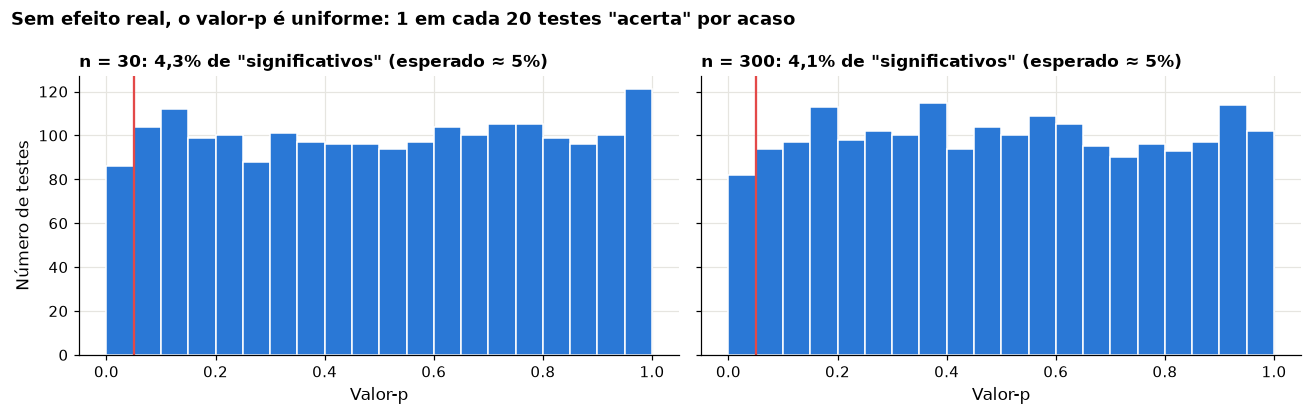

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, n in zip(axes, (30, 300)):
    a, b = rng.choice(mt, size=(2000, n)), rng.choice(mt, size=(2000, n))
    p = stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue
    ax.hist(p, bins=20, range=(0, 1), color=AZUL, edgecolor='white')
    ax.axvline(0.05, color=VERMELHO, lw=1.5)
    ax.set_title(f'n = {n}: {br(100 * (p < 0.05).mean())}% de "significativos" (esperado ≈ 5%)', fontsize=11)
    print(f'n = {n}: {br(100 * (p < 0.05).mean())}% dos 2.000 testes com p < 0,05')
    ax.set_xlabel('Valor-p')
axes[0].set_ylabel('Número de testes')
fig.suptitle('Sem efeito real, o valor-p é uniforme: 1 em cada 20 testes "acerta" por acaso', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Ex. 1 — Linguagens: escolas federais × privadas (t de Welch)

Em turmas anteriores, sorteávamos 1.000 alunos de cada grupo e rodávamos o teste. Ficavam três perguntas sem resposta: **por que 1.000?** **O que muda se fossem 100 ou 100.000?** **A diferença é grande?** Agora o percurso é: (a) olhar a "verdade" da população; (b) planejar n pelo menor efeito relevante; (c) testar uma amostra; (d) ver o que acontece com o valor-p e com o efeito quando n muda.

In [46]:
# (a) A "verdade" no laboratório: todos os concluintes de 2023 que informaram escola federal ou privada
lc_fed = base.loc[base.TP_DEPENDENCIA_ADM_ESC == 1, 'NU_NOTA_LC'].to_numpy()
lc_priv = base.loc[base.TP_DEPENDENCIA_ADM_ESC == 4, 'NU_NOTA_LC'].to_numpy()
D_VERDADEIRO = d_cohen(lc_fed, lc_priv)
print(f'Federais: N = {br(len(lc_fed), 0)}, média {br(lc_fed.mean())} (dp {br(lc_fed.std(ddof=1))})')
print(f'Privadas: N = {br(len(lc_priv), 0)}, média {br(lc_priv.mean())} (dp {br(lc_priv.std(ddof=1))})')
print(f'Diferença verdadeira = {br(lc_fed.mean() - lc_priv.mean())} pontos | d verdadeiro = {br(D_VERDADEIRO, 3)} ({magnitude(D_VERDADEIRO)})')
print(f'Razão de variâncias = {br(max(lc_fed.var(), lc_priv.var()) / min(lc_fed.var(), lc_priv.var()), 2)} (Welch não exige igualdade)')

Federais: N = 43.273, média 552,4 (dp 64,5)
Privadas: N = 212.640, média 562,0 (dp 64,6)
Diferença verdadeira = -9,6 pontos | d verdadeiro = -0,149 (desprezível)
Razão de variâncias = 1,00 (Welch não exige igualdade)


In [47]:
# (b) Planejamento: quantos alunos por grupo para detectar o MENOR efeito relevante (d = 0,2)?
analise_poder = TTestIndPower()
n_planejado = int(np.ceil(analise_poder.solve_power(effect_size=0.2, alpha=0.05, power=0.80)))
dp_comb = np.sqrt((lc_fed.var(ddof=1) + lc_priv.var(ddof=1)) / 2)
print(f'd = 0,2 corresponde a ≈ {br(0.2 * dp_comb)} pontos de LC')
print(f'n por grupo para poder de 80% (α = 0,05, bilateral): {n_planejado}')
for d_alvo in (0.1, 0.5, 0.8):
    print(f'  para d = {d_alvo}: n = {int(np.ceil(analise_poder.solve_power(effect_size=d_alvo, alpha=0.05, power=0.80)))} por grupo')

d = 0,2 corresponde a ≈ 12,9 pontos de LC
n por grupo para poder de 80% (α = 0,05, bilateral): 394
  para d = 0.1: n = 1571 por grupo
  para d = 0.5: n = 64 por grupo
  para d = 0.8: n = 26 por grupo


In [48]:
# (c) Uma amostra com o n planejado — o que o analista teria na vida real
a = rng.choice(lc_fed, n_planejado, replace=False)
b = rng.choice(lc_priv, n_planejado, replace=False)
ex1 = comparar(a, b, 'Federais', 'Privadas')
relatar(ex1)
MARGEM_LC = 0.2 * dp_comb          # menor efeito relevante (d = 0,2) convertido em pontos de LC
print(f"Leitura com a margem de relevância de ±{br(MARGEM_LC)} pontos: {classificar(ex1['IC95% inf'], ex1['IC95% sup'], MARGEM_LC)}")
ex1.to_frame('Ex. 1 (amostra)').T

Federais − Privadas: diferença de -5,7 pontos (IC95% [-14,3; 2,9]); d = -0,09 (efeito desprezível); p 0,196; n = 394 e 394.
Leitura com a margem de relevância de ±12,9 pontos: inconclusivo


,grupo A,grupo B,n A,n B,média A,média B,diferença (A−B),IC95% inf,IC95% sup,t,p,d de Cohen,magnitude
Ex. 1 (amostra),Federais,Privadas,394,394,553.249746,558.943655,-5.693909,-14.334037,2.94622,-1.293623,0.196176,-0.092167,desprezível


**Como ler:** o IC da diferença diz o tamanho plausível do efeito; o valor-p diz só se zero é plausível; o **d** põe a diferença na régua do desvio padrão. Compare o IC com a diferença verdadeira impressa em (a).

Na execução de referência (semente 2023), o teste **não** rejeita H₀ (p ≈ 0,20). Isso **não** prova que federais e privadas são iguais: o IC vai de cerca de −14 a +3 pontos e ainda inclui uma diferença no limite do relevante. A leitura honesta é **inconclusivo quanto à relevância**.

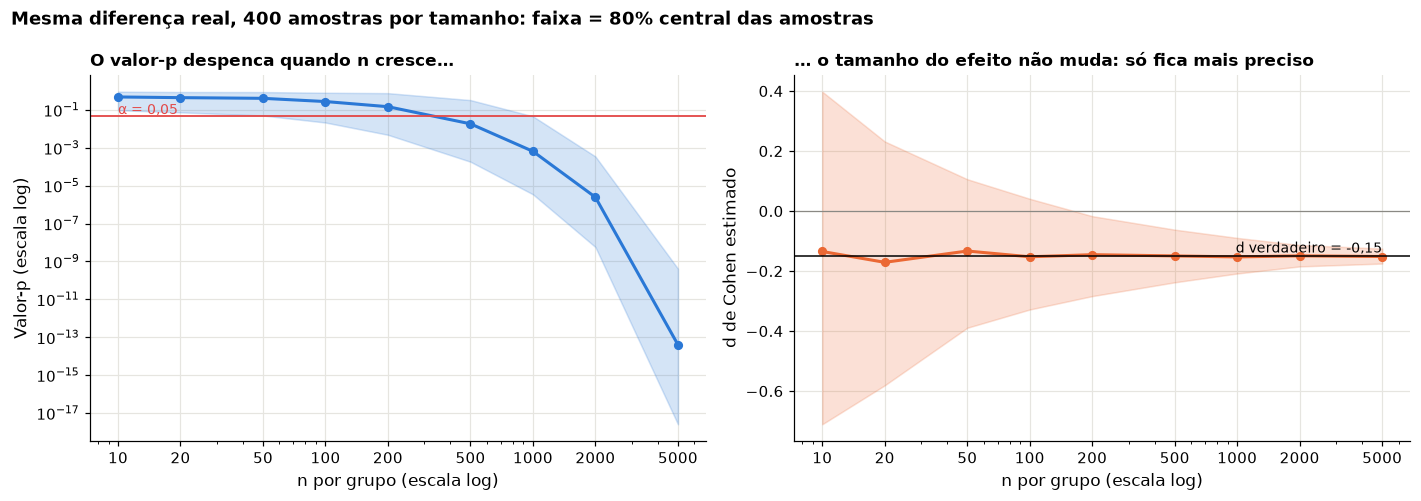

,n por grupo,poder empírico (%),poder teórico (%),p mediano
0,10,5.25,6.154,0.479
1,20,7.25,7.459,0.441
2,50,10.00,11.453,0.406
3,100,18.75,18.282,0.275
4,200,31.25,31.913,0.147
5,500,65.25,65.463,0.018
6,1000,91.00,91.560,0.001
7,2000,99.75,99.710,0.000
8,5000,100.00,100.000,0.000


In [49]:
# (d) O experimento central: mesma diferença real, n diferente
ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
reps = 400
p_res, d_res, poder = [], [], []
for n in ns:
    A, B = rng.choice(lc_fed, size=(reps, n)), rng.choice(lc_priv, size=(reps, n))
    p = stats.ttest_ind(A, B, axis=1, equal_var=False).pvalue
    sp = np.sqrt((A.var(axis=1, ddof=1) + B.var(axis=1, ddof=1)) / 2)
    d = (A.mean(axis=1) - B.mean(axis=1)) / sp
    p_res.append(p); d_res.append(d); poder.append(100 * (p < 0.05).mean())
p_res, d_res = np.array(p_res), np.array(d_res)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.fill_between(ns, np.percentile(p_res, 10, axis=1), np.percentile(p_res, 90, axis=1), color=AZUL, alpha=0.2)
ax.plot(ns, np.median(p_res, axis=1), 'o-', color=AZUL, lw=2, ms=5)
ax.axhline(0.05, color=VERMELHO, lw=1.2)
ax.text(ns[0], 0.06, 'α = 0,05', color=VERMELHO, fontsize=9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(ns, [str(v) for v in ns])
ax.set_xlabel('n por grupo (escala log)'); ax.set_ylabel('Valor-p (escala log)')
ax.set_title('O valor-p despenca quando n cresce…', fontsize=11)

ax = axes[1]
ax.fill_between(ns, np.percentile(d_res, 10, axis=1), np.percentile(d_res, 90, axis=1), color=LARANJA, alpha=0.2)
ax.plot(ns, np.median(d_res, axis=1), 'o-', color=LARANJA, lw=2, ms=5)
ax.axhline(D_VERDADEIRO, color='black', lw=1)
ax.text(ns[-1], D_VERDADEIRO, f' d verdadeiro = {br(D_VERDADEIRO, 2)}', va='bottom', ha='right', fontsize=9)
ax.axhline(0, color=CINZA, lw=0.8)
ax.set_xscale('log')
ax.set_xticks(ns, [str(v) for v in ns])
ax.set_xlabel('n por grupo (escala log)'); ax.set_ylabel('d de Cohen estimado')
ax.set_title('… o tamanho do efeito não muda: só fica mais preciso', fontsize=11)
fig.suptitle('Mesma diferença real, 400 amostras por tamanho: faixa = 80% central das amostras', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm5_p_vs_d_por_n')
plt.show()

tabela_poder = pd.DataFrame({'n por grupo': ns, 'poder empírico (%)': poder,
                             'poder teórico (%)': [100 * analise_poder.power(effect_size=abs(D_VERDADEIRO), nobs1=n, alpha=0.05) for n in ns],
                             'p mediano': np.median(p_res, axis=1)})
tabela_poder.round(3)

**Três lições do gráfico:**
1. Com n pequeno, a mesma diferença real dá "não significativo" na maioria das amostras: **p > 0,05 não prova igualdade** (erro tipo II).
2. Com n grande, **tudo** fica significativo. Aqui a diferença verdadeira (d ≈ 0,15, cerca de 10 pontos) está **abaixo** do menor efeito relevante do pré-registro (d = 0,2). Mesmo assim, com n = 1.000 por grupo, o n usado em turmas anteriores, cerca de 9 em cada 10 amostras dão "significativo". **Significativo e irrelevante.** Em bases com milhões de linhas, o valor-p perde utilidade e o que decide é o **tamanho do efeito**.
3. O d estimado **oscila em torno do mesmo valor** em qualquer n; o que muda é a precisão. O n deve ser escolhido pela **precisão desejada** ou pelo **menor efeito relevante** (seção b), e não por hábito.

> **Sobre o pingouin, usado em turmas anteriores:** a coluna `power` de `pingouin.ttest` é o "poder alcançado", calculado com o **próprio d observado** (veja o código-fonte da função). Esse "poder observado" é só outra forma de reescrever o valor-p e não informa o poder do estudo (Hoenig e Heisey, 2001). O poder serve para **planejar** n antes da coleta, como em (b).

## 4.4 A régua do tamanho do efeito (população inteira)

Todas as comparações abaixo têm p < 0,001. O que as distingue é o tamanho.

,n A,n B,diferença (A−B),IC95% inf,IC95% sup,p,d de Cohen,magnitude
comparação,,,,,,,,
MT: privada × pública (TP_ESCOLA),219207,783634,121.800,121.237,122.362,0.0,1.086,grande
MT: renda > R$ 6.600 × renda ≤ R$ 1.320,377805,877472,168.476,168.036,168.915,0.0,1.576,grande
MT: homens × mulheres,983373,1585817,46.543,46.228,46.858,0.0,0.379,pequeno
LC: privada × federal,212640,43273,9.643,8.976,10.310,0.0,0.149,desprezível
"CH × LC (pareado, d_z)",2569190,2569190,6.570,6.502,6.637,0.0,0.119,desprezível


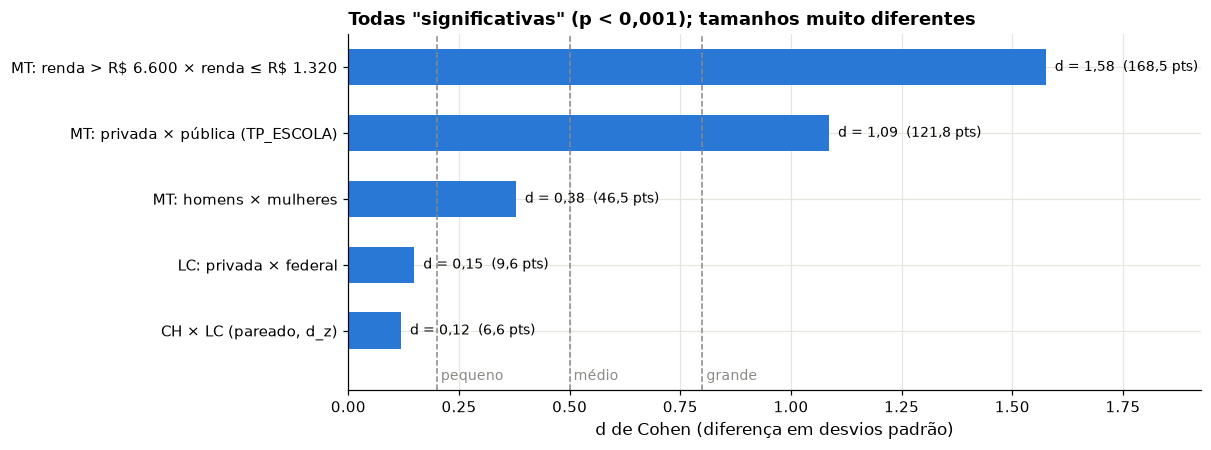

In [50]:
pub = base.loc[base.TP_ESCOLA == 2, 'NU_NOTA_MT']; priv = base.loc[base.TP_ESCOLA == 3, 'NU_NOTA_MT']
masc = base.loc[base.TP_SEXO == 'M', 'NU_NOTA_MT']; fem = base.loc[base.TP_SEXO == 'F', 'NU_NOTA_MT']
alta = base.loc[base.RENDA_4 == '4) acima de R$ 6.600', 'NU_NOTA_MT']; baixa = base.loc[base.RENDA_4 == '1) até R$ 1.320', 'NU_NOTA_MT']
regua = pd.DataFrame([
    comparar(priv, pub, 'MT: privada', 'pública (TP_ESCOLA)'),
    comparar(alta, baixa, 'MT: renda > R$ 6.600', 'renda ≤ R$ 1.320'),
    comparar(masc, fem, 'MT: homens', 'mulheres'),
    comparar(lc_priv, lc_fed, 'LC: privada', 'federal'),
])
dif_par = base.NU_NOTA_CH - base.NU_NOTA_LC          # pareado: o mesmo participante nas duas provas
t_par = stats.ttest_rel(base.NU_NOTA_CH, base.NU_NOTA_LC)
regua.loc[len(regua)] = {'grupo A': 'CH', 'grupo B': 'LC (pareado, d_z)', 'n A': len(dif_par), 'n B': len(dif_par),
                         'média A': base.NU_NOTA_CH.mean(), 'média B': base.NU_NOTA_LC.mean(),
                         'diferença (A−B)': dif_par.mean(), 'IC95% inf': t_par.confidence_interval().low,
                         'IC95% sup': t_par.confidence_interval().high, 't': t_par.statistic, 'p': t_par.pvalue,
                         'd de Cohen': dif_par.mean() / dif_par.std(ddof=1), 'magnitude': magnitude(dif_par.mean() / dif_par.std(ddof=1))}
regua['comparação'] = regua['grupo A'] + ' × ' + regua['grupo B']
display(regua.set_index('comparação')[['n A', 'n B', 'diferença (A−B)', 'IC95% inf', 'IC95% sup', 'p', 'd de Cohen', 'magnitude']].round(3))

ordem = regua.sort_values('d de Cohen')
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(range(len(ordem)), ordem['d de Cohen'], color=AZUL, height=0.55)
ax.set_yticks(range(len(ordem)), [c.replace('$', r'\$') for c in ordem['comparação']])   # "$" em rótulo vira fórmula
for v, lab in ((0.2, 'pequeno'), (0.5, 'médio'), (0.8, 'grande')):
    ax.axvline(v, color=CINZA, lw=1, ls='--')
    ax.text(v, -0.75, f' {lab}', color=CINZA, fontsize=9)
ax.set_ylim(-0.9, len(ordem) - 0.5)
for i, (d, dif) in enumerate(zip(ordem['d de Cohen'], ordem['diferença (A−B)'])):
    ax.text(d + 0.02, i, f'd = {br(d, 2)}  ({br(dif)} pts)', va='center', fontsize=9)
ax.set_xlim(0, max(1.3, ordem['d de Cohen'].max() + 0.35))
ax.set_xlabel('d de Cohen (diferença em desvios padrão)')
ax.set_title('Todas "significativas" (p < 0,001); tamanhos muito diferentes')
salvar(fig, 'm5_regua_efeito')
plt.show()

*Cuidados de leitura:* todas são comparações **observacionais**. A diferença entre escolas mistura renda, capital cultural e seleção de alunos; não é "o efeito da escola". As provas de CH e LC têm itens e escalas próprias, então a comparação pareada entre áreas tem sentido limitado. As convenções de Cohen são referência: a relevância de verdade se decide pela **pergunta de gestão**.

## 4.5 Ex. 2 — ANOVA: média geral em seis UFs

Em turmas anteriores, o pós-teste de Tukey era lido assim: *"pares com p ≥ 0,05 têm desempenho estatisticamente equivalente"*. **Essa leitura está errada:** não rejeitar H₀ não prova igualdade. Para afirmar equivalência é preciso fixar uma **margem de relevância** (aqui, ±10 pontos) e verificar se o **IC da diferença cabe inteiro dentro dela**.

In [51]:
UFS = ['SP', 'MG', 'BA', 'RJ', 'RS', 'DF']
pop_uf = base.loc[base.SG_UF_PROVA.isin(UFS), ['SG_UF_PROVA', 'MEDIA_GERAL']]
amostra_uf = pop_uf.sample(1250, random_state=SEMENTE)          # o n usado em turmas anteriores

grupos = [g.MEDIA_GERAL.to_numpy() for _, g in amostra_uf.groupby('SG_UF_PROVA')]
F, pF = stats.f_oneway(*grupos)
print(f'ANOVA (amostra de 1.250): F = {br(F, 2)}; p {fmt_p(pF)}; η² = {br(eta2(amostra_uf.MEDIA_GERAL, amostra_uf.SG_UF_PROVA), 3)}')
print(f'η² na população das 6 UFs = {br(eta2(pop_uf.MEDIA_GERAL, pop_uf.SG_UF_PROVA), 3)}')
amostra_uf.groupby('SG_UF_PROVA').MEDIA_GERAL.agg(['count', 'mean', 'std']).sort_values('mean', ascending=False).round(1)

ANOVA (amostra de 1.250): F = 8,65; p < 0,001; η² = 0,034
η² na população das 6 UFs = 0,027


,count,mean,std
SG_UF_PROVA,,,
RS,116,572.7,83.4
MG,264,572.2,82.6
DF,48,571.4,83.9
SP,418,570.4,81.6
RJ,185,567.8,87.6
BA,219,529.5,90.1


In [52]:
MARGEM = 10   # pontos: menor diferença de média geral relevante para a decisão (definida no pré-registro)

def tukey_tabela(df_):
    tk = pairwise_tukeyhsd(df_.MEDIA_GERAL, df_.SG_UF_PROVA, alpha=0.05)
    t = pd.DataFrame(tk.summary().data[1:], columns=tk.summary().data[0])
    t['par'] = t.group1 + ' × ' + t.group2
    t['leitura antiga (p ≥ 0,05 = "equivalentes")'] = np.where(t['p-adj'] >= 0.05, 'equivalentes', 'diferentes')
    t['leitura correta (IC × margem de ±10)'] = [classificar(lo, hi, MARGEM) for lo, hi in zip(t.lower, t.upper)]
    return t

tk_amostra = tukey_tabela(amostra_uf)
tk_amostra[['par', 'meandiff', 'lower', 'upper', 'p-adj', 'leitura antiga (p ≥ 0,05 = "equivalentes")', 'leitura correta (IC × margem de ±10)']]

,par,meandiff,lower,upper,p-adj,"leitura antiga (p ≥ 0,05 = ""equivalentes"")",leitura correta (IC × margem de ±10)
0,BA × DF,41.8756,3.4470,80.3041,0.0234,diferentes,diferente; relevância incerta
1,BA × MG,42.6872,20.6482,64.7261,0.0000,diferentes,diferença relevante
2,BA × RJ,38.2606,14.1824,62.3388,0.0001,diferentes,diferença relevante
3,BA × RS,43.1217,15.4323,70.8110,0.0001,diferentes,diferença relevante
4,BA × SP,40.8719,20.7578,60.9860,0.0000,diferentes,diferença relevante
5,DF × MG,0.8116,-37.0236,38.6468,1.0000,equivalentes,inconclusivo
6,DF × RJ,-3.6149,-42.6732,35.4433,0.9998,equivalentes,inconclusivo
7,DF × RS,1.2461,-40.1361,42.6284,1.0000,equivalentes,inconclusivo
8,DF × SP,-1.0036,-37.7510,35.7437,1.0000,equivalentes,inconclusivo
9,MG × RJ,-4.4266,-27.5460,18.6929,0.9942,equivalentes,inconclusivo


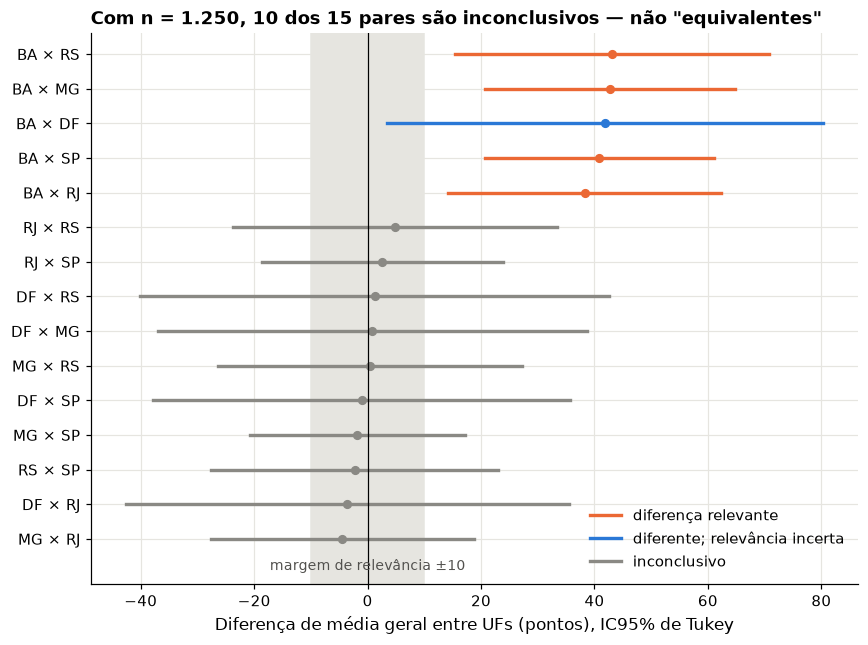

In [53]:
fig, ax = plt.subplots(figsize=(9, 6.5))
t = tk_amostra.sort_values('meandiff').reset_index(drop=True)
ax.axvspan(-MARGEM, MARGEM, color='#e6e5e0', zorder=0)
ax.text(0, -0.9, f'margem de relevância ±{MARGEM}', ha='center', fontsize=9, color='#52514e')
ax.set_ylim(-1.3, len(t) - 0.4)
cores = {'diferença relevante': LARANJA, 'inconclusivo': CINZA, 'equivalente na prática': VERDE,
         'diferente, mas irrelevante': VERDE, 'diferente; relevância incerta': AZUL}
for i, r in t.iterrows():
    c = cores[r['leitura correta (IC × margem de ±10)']]
    ax.plot([r.lower, r.upper], [i, i], color=c, lw=2.2)
    ax.plot(r.meandiff, i, 'o', color=c, ms=5)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(t)), t.par)
ax.set_xlabel('Diferença de média geral entre UFs (pontos), IC95% de Tukey')
handles = [plt.Line2D([], [], color=c, lw=2.2, label=l) for l, c in
           [('diferença relevante', LARANJA), ('diferente; relevância incerta', AZUL), ('inconclusivo', CINZA)]]
ax.legend(handles=handles, loc='lower right')
n_inc = (t['leitura correta (IC × margem de ±10)'] == 'inconclusivo').sum()
ax.set_title(f'Com n = 1.250, {n_inc} dos {len(t)} pares são inconclusivos — não "equivalentes"')
salvar(fig, 'm5_tukey_margem')
plt.show()

In [54]:
# A mesma análise com TODOS os participantes das seis UFs: os IC ficam estreitos e a margem decide
tk_pop = tukey_tabela(pop_uf)
print(f'n = {br(len(pop_uf), 0)}')
tk_pop[['par', 'meandiff', 'lower', 'upper', 'p-adj', 'leitura correta (IC × margem de ±10)']].round(2)

n = 1.187.611


,par,meandiff,lower,upper,p-adj,leitura correta (IC × margem de ±10)
0,BA × DF,33.99,32.78,35.20,0.0,diferença relevante
1,BA × MG,39.27,38.56,39.99,0.0,diferença relevante
2,BA × RJ,31.69,30.91,32.46,0.0,diferença relevante
3,BA × RS,31.77,30.87,32.68,0.0,diferença relevante
4,BA × SP,38.05,37.40,38.69,0.0,diferença relevante
5,DF × MG,5.28,4.08,6.48,0.0,"diferente, mas irrelevante"
6,DF × RJ,-2.30,-3.54,-1.07,0.0,"diferente, mas irrelevante"
7,DF × RS,-2.22,-3.54,-0.90,0.0,"diferente, mas irrelevante"
8,DF × SP,4.05,2.90,5.21,0.0,"diferente, mas irrelevante"
9,MG × RJ,-7.59,-8.34,-6.83,0.0,"diferente, mas irrelevante"


**Leitura:** com a população, quase todos os pares são "significativos" (p ajustado < 0,05), mas vários são **diferentes e irrelevantes** (a diferença inteira cabe na margem de ±10 pontos). Com a amostra de 1.250, pares que a leitura antiga chamava de "equivalentes" eram, na verdade, **inconclusivos**: o IC era largo demais para dizer qualquer coisa.

In [55]:
# Contraste: a UF explica pouco da variação da média geral; a renda explica muito mais
print(f'η² da UF (6 UFs, população)          = {br(eta2(pop_uf.MEDIA_GERAL, pop_uf.SG_UF_PROVA), 3)}')
print(f'η² da renda em 4 faixas (Brasil)      = {br(eta2(base.MEDIA_GERAL, base.RENDA_4), 3)}')
print(f'η² da renda em 4 faixas — MT (Brasil) = {br(eta2(base.NU_NOTA_MT, base.RENDA_4), 3)}')
anova_renda = base.groupby('RENDA_4').NU_NOTA_MT.agg(n='count', média='mean', dp='std')
grupos_r = [g.to_numpy() for _, g in base.groupby('RENDA_4').NU_NOTA_MT]
print(f'ANOVA MT × renda: F = {br(stats.f_oneway(*grupos_r).statistic, 0)}; razão máx/mín de variâncias = {br(anova_renda.dp.max() ** 2 / anova_renda.dp.min() ** 2, 2)}')
anova_renda.round(1)

η² da UF (6 UFs, população)          = 0,027


η² da renda em 4 faixas (Brasil)      = 0,215


η² da renda em 4 faixas — MT (Brasil) = 0,217


ANOVA MT × renda: F = 237.427; razão máx/mín de variâncias = 1,47


,n,média,dp
RENDA_4,,,
1) até R$ 1.320,877472,479.6,100.1
2) R$ 1.320–3.300,885423,531.7,111.6
3) R$ 3.300–6.600,428490,589.0,118.4
4) acima de R$ 6.600,377805,648.1,121.3


## 4.6 Ex. 3 — Qui-quadrado: escolaridade do pai × renda familiar

In [56]:
# Todos os inscritos (como nas turmas anteriores); "Não sei" (H) fica de fora
INSTR_5 = {**dict.fromkeys('ABC', '1) Fund. incompleto'), 'D': '2) Fund. completo', 'E': '3) Médio completo',
           'F': '4) Superior completo', 'G': '5) Pós-graduação'}
qq = insc.loc[insc.Q001 != 'H', ['Q001', 'Q006']].copy()
qq['instr_pai'] = qq.Q001.map(INSTR_5)
qq['renda'] = qq.Q006.map(RENDA_4)
tab = pd.crosstab(qq.instr_pai, qq.renda)
chi2, p, gl, esperado = stats.chi2_contingency(tab)
V = stats.contingency.association(tab.to_numpy(), method='cramer')
print(f'χ² = {br(chi2, 0)}; gl = {gl}; p {fmt_p(p)}; menor frequência esperada = {br(esperado.min(), 0)}; V de Cramér = {br(V, 3)}')
display(tab)

χ² = 1.199.953; gl = 12; p < 0,001; menor frequência esperada = 32.708; V de Cramér = 0,337


renda,1) até R$ 1.320,2) R$ 1.320–3.300,3) R$ 3.300–6.600,4) acima de R$ 6.600
instr_pai,,,,
1) Fund. incompleto,765306,486049,105437,31308
2) Fund. completo,172624,182948,59716,22851
3) Médio completo,317873,452303,226172,117816
4) Superior completo,32670,84021,91329,125961
5) Pós-graduação,13605,35791,53594,153055


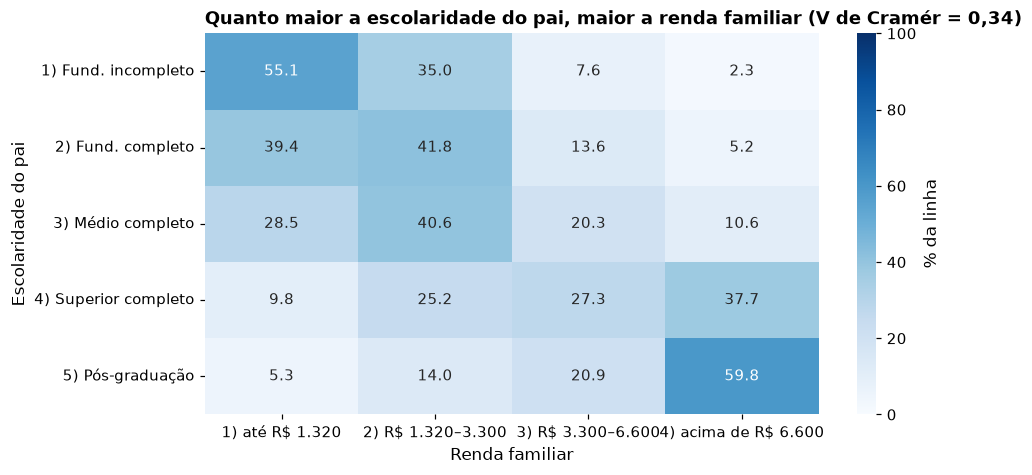

Amostra n = 1.000: χ² = 291,5; p < 0,001; V = 0,312; menor esperado = 7,2


In [57]:
# ONDE está a associação: percentuais por linha (para cada escolaridade do pai, a distribuição da renda)
pct = pd.crosstab(qq.instr_pai, qq.renda, normalize='index') * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pct, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, cbar_kws={'label': '% da linha'}, ax=ax)
ax.set_xlabel('Renda familiar'); ax.set_ylabel('Escolaridade do pai')
ax.tick_params(axis='x', rotation=0)
ax.set_title(f'Quanto maior a escolaridade do pai, maior a renda familiar (V de Cramér = {br(V, 2)})')
salvar(fig, 'm5_quiquadrado_pai_renda')
plt.show()

# A mesma pergunta numa amostra de 1.000 inscritos: a força (V) é parecida; o p é que muda
sub = qq.sample(1000, random_state=SEMENTE)
tab_s = pd.crosstab(sub.instr_pai, sub.renda)
c2s, ps, _, es = stats.chi2_contingency(tab_s)
print(f'Amostra n = 1.000: χ² = {br(c2s, 1)}; p {fmt_p(ps)}; V = {br(stats.contingency.association(tab_s.to_numpy(), method="cramer"), 3)}; '
      f'menor esperado = {br(es.min(), 1)}')

In [58]:
# Ligação com o Módulo 4: presença em MT × renda (todos os inscritos) — a origem do viés de seleção
tab_pres = pd.crosstab(insc.Q006.map(RENDA_4), insc.TP_PRESENCA_MT == 1).rename(columns={False: 'não presentes', True: 'presentes'})
c2p, pp, glp, ep_ = stats.chi2_contingency(tab_pres)
tab_pres['% presentes'] = 100 * tab_pres.presentes / tab_pres.sum(axis=1)
print(f'χ² = {br(c2p, 0)}; gl = {glp}; p {fmt_p(pp)}; V de Cramér = {br(stats.contingency.association(tab_pres[["não presentes", "presentes"]].to_numpy(), method="cramer"), 3)}')
tab_pres.round(1)

χ² = 95.031; gl = 3; p < 0,001; V de Cramér = 0,155


TP_PRESENCA_MT,não presentes,presentes,% presentes
Q006,,,
1) até R$ 1.320,573015,940309,62.1
2) R$ 1.320–3.300,458316,923986,66.8
3) R$ 3.300–6.600,130667,441283,77.2
4) acima de R$ 6.600,79530,386849,82.9


## 4.7 Comparações múltiplas: quem procura, acha

In [59]:
# 100 testes entre duas metades SORTEADAS de MT (H0 verdadeira em todos)
ps = []
for _ in range(100):
    idx = rng.choice(len(mt), 1000, replace=False)
    ps.append(stats.ttest_ind(mt[idx[:500]], mt[idx[500:]], equal_var=False).pvalue)
ps = np.array(ps)
print(f'p < 0,05 em {(ps < 0.05).sum()} de 100 testes | menor p = {ps.min():.4f}')
for metodo, nome in (('bonferroni', 'Bonferroni'), ('holm', 'Holm'), ('fdr_bh', 'FDR (Benjamini-Hochberg)')):
    print(f'  rejeições após correção de {nome}: {multipletests(ps, alpha=0.05, method=metodo)[0].sum()}')

p < 0,05 em 7 de 100 testes | menor p = 0.0066
  rejeições após correção de Bonferroni: 0
  rejeições após correção de Holm: 0
  rejeições após correção de FDR (Benjamini-Hochberg): 0


### IA — Prompts do Módulo 5

**Prompt 1 — escolher o teste e planejar n (antes de ver os dados)**
```text
Pergunta de gestão: as notas de Linguagens diferem entre alunos de escolas federais e privadas?
Dados: NU_NOTA_LC (numérica contínua, 0–1000), TP_DEPENDENCIA_ADM_ESC (1 = federal,
4 = privada; só concluintes de 2023); observacional (não randomizado).
Plano: hipótese bilateral, alfa = 0,05, menor efeito relevante d = 0,2, decidido antes da análise.

Tarefa:
1) Recomende o teste e justifique pela natureza das variáveis e do delineamento.
2) Calcule o n por grupo para poder de 80% com statsmodels (TTestIndPower), mostrando o código.
3) Liste as suposições e como verificar cada uma no meu caso (com o código).
4) Diga quais medidas de efeito e de incerteza devo reportar (efeito, IC, tamanho do efeito).
5) Alerte para erros de interpretação que esse delineamento observacional permite.
6) Escreva o código Python (scipy), com semente fixa e comentários em português.
Não calcule resultados; apenas escreva o código.
```

**Prompt 2 — validação por simulação (o "controle negativo")**
```text
Tenho um pipeline de análise (função `analisar(df)` que filtra, testa e retorna o valor-p).
Escreva código para: (1) embaralhar aleatoriamente a coluna de grupo 1.000 vezes, mantendo
o restante igual; (2) rodar `analisar` em cada versão; (3) estimar a proporção de valores-p < 0,05;
(4) plotar o histograma dos valores-p. Explique o que eu devo esperar se o pipeline está correto
e o que significa se a proporção for muito maior que 5%.
```

**Prompt 3 — redigir o resultado sem inflar a conclusão**
```text
Resultado: [colar a frase de `relatar()` da régua de efeitos: privada × pública em MT].
Delineamento observacional. Escreva um parágrafo para um relatório técnico
e três bullets para a diretoria. Regras: não use "prova", "causa" nem "efeito da escola";
mencione o tamanho do efeito e o IC; inclua uma limitação sobre a população analisada
(só concluintes de 2023 que informaram escola) e uma sobre fatores de confusão.
```

In [60]:
# Verificação do Prompt 1: o n que a IA calcular deve bater com este
print('n por grupo (d = 0,2; poder 80%; α = 0,05):', n_planejado)

# Verificação do Prompt 2: controle negativo sobre o pipeline do Ex. 1
amostra_ex1 = pd.DataFrame({'nota': np.r_[a, b], 'grupo': ['federal'] * len(a) + ['privada'] * len(b)})

def analisar(df_):
    return stats.ttest_ind(df_.loc[df_.grupo == 'federal', 'nota'], df_.loc[df_.grupo == 'privada', 'nota'], equal_var=False).pvalue

p_embaralhado = np.array([analisar(amostra_ex1.assign(grupo=rng.permutation(amostra_ex1.grupo.to_numpy())))
                          for _ in range(1000)])
print(f'Controle negativo: {br(100 * (p_embaralhado < 0.05).mean())}% de p < 0,05 com rótulos embaralhados (esperado ≈ 5%)')
print(f'p com os rótulos verdadeiros: {fmt_p(analisar(amostra_ex1))}')

# Frase para colar no Prompt 3
relatar(regua.iloc[0])

n por grupo (d = 0,2; poder 80%; α = 0,05): 394


Controle negativo: 4,6% de p < 0,05 com rótulos embaralhados (esperado ≈ 5%)
p com os rótulos verdadeiros: 0,196
MT: privada − pública (TP_ESCOLA): diferença de 121,8 pontos (IC95% [121,2; 122,4]); d = 1,09 (efeito grande); p < 0,001; n = 219.207 e 783.634.


---
# Parte 5 — Correlação e regressão (Módulo 6)

> *"Correlação resume a força de uma relação linear; regressão transforma essa relação numa equação que explica e prevê. Nenhuma das duas, sozinha, prova causa."*

## 5.1 Correlação e o tamanho da amostra

In [61]:
print(corr.round(3))
cn, mtv = base.NU_NOTA_CN.to_numpy(), base.NU_NOTA_MT.to_numpy()
r_pop = np.corrcoef(cn, mtv)[0, 1]
idx = rng.choice(len(cn), 300_000, replace=False)
print(f'\nCN × MT: Pearson r = {br(r_pop, 3)} | Spearman (300 mil pares) = {br(stats.spearmanr(cn[idx], mtv[idx]).statistic, 3)}')

linhas = []
for n in (10, 30, 100, 1000):
    ii = rng.integers(0, len(cn), size=(1000, n))
    X, Y = cn[ii], mtv[ii]
    Xc, Yc = X - X.mean(axis=1, keepdims=True), Y - Y.mean(axis=1, keepdims=True)
    r = (Xc * Yc).sum(axis=1) / np.sqrt((Xc ** 2).sum(axis=1) * (Yc ** 2).sum(axis=1))
    linhas.append({'n': n, 'r mediano': np.median(r), 'r (2,5%)': np.percentile(r, 2.5), 'r (97,5%)': np.percentile(r, 97.5)})
print(f'\nVariação de r em 1.000 amostras (r verdadeiro = {br(r_pop, 3)}):')
pd.DataFrame(linhas).set_index('n').round(2)

                      Ciências da Natureza  Ciências Humanas  Linguagens  Matemática  Redação
Ciências da Natureza                 1.000             0.655       0.633       0.674    0.465
Ciências Humanas                     0.655             1.000       0.761       0.654    0.488
Linguagens                           0.633             0.761       1.000       0.639    0.488
Matemática                           0.674             0.654       0.639       1.000    0.529
Redação                              0.465             0.488       0.488       0.529    1.000

CN × MT: Pearson r = 0,674 | Spearman (300 mil pares) = 0,638

Variação de r em 1.000 amostras (r verdadeiro = 0,674):


,r mediano,"r (2,5%)","r (97,5%)"
n,,,
10,0.70,0.06,0.93
30,0.68,0.40,0.85
100,0.68,0.54,0.78
1000,0.67,0.63,0.71


## 5.2 Regressão simples: MT ~ CN, e o diagnóstico que o R² não mostra

In [62]:
modelo_cn = sm.OLS(mtv, sm.add_constant(cn)).fit()
b0, b1 = modelo_cn.params
ic_b1 = modelo_cn.conf_int()[1]
rse = np.sqrt(modelo_cn.scale)
print(f'MT = {br(b0, 2)} + {br(b1, 3)} × CN | R² = {br(modelo_cn.rsquared, 3)} | erro padrão residual = {br(rse)} pontos')
print(f'IC95% da inclinação = [{br(ic_b1[0], 3)}; {br(ic_b1[1], 3)}]')
print(f'Previsão para CN = 500: {br(b0 + b1 * 500)} | CN = 700: {br(b0 + b1 * 700)} (erro típico ±{br(rse, 0)})')

# Verificação independente: b = r · s_y / s_x
print(f'Conferência: r·s_y/s_x = {br(r_pop * mtv.std() / cn.std(), 3)}')

MT = 5,03 + 1,069 × CN | R² = 0,455 | erro padrão residual = 92,3 pontos
IC95% da inclinação = [1,068; 1,071]
Previsão para CN = 500: 539,6 | CN = 700: 753,4 (erro típico ±92)
Conferência: r·s_y/s_x = 1,069


,count,mean,std
faixa de CN,,,
"(0, 400]",243571,39.8,87.1
"(400, 450]",470798,-0.5,85.7
"(450, 500]",608434,-14.6,93.0
"(500, 550]",570037,-15.5,97.3
"(550, 600]",409593,-1.1,93.5
"(600, 650]",170934,26.9,77.8
"(650, 1000]",95823,43.0,59.7


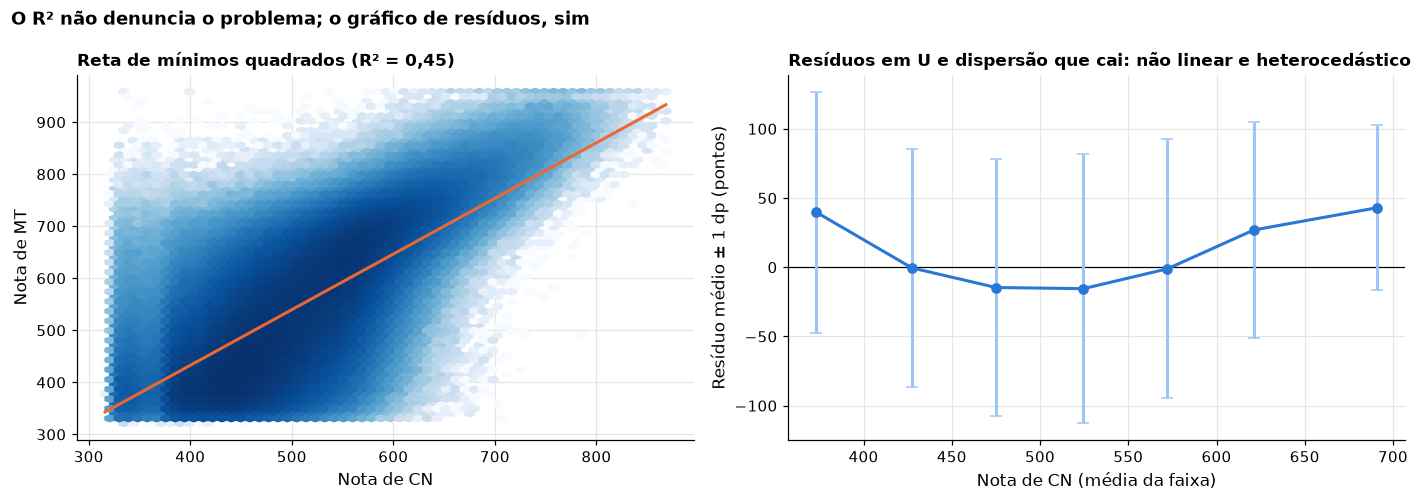

In [63]:
residuos = modelo_cn.resid
faixas = pd.cut(cn, [0, 400, 450, 500, 550, 600, 650, 1000])
diag = pd.DataFrame({'faixa de CN': faixas, 'resíduo': residuos}).groupby('faixa de CN', observed=True).resíduo.agg(['count', 'mean', 'std'])
display(diag.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.hexbin(cn, mtv, gridsize=60, cmap='Blues', bins='log', mincnt=1)
xs = np.array([cn.min(), cn.max()])
ax.plot(xs, b0 + b1 * xs, color=LARANJA, lw=2)
ax.set_xlabel('Nota de CN'); ax.set_ylabel('Nota de MT')
ax.set_title(f'Reta de mínimos quadrados (R² = {br(modelo_cn.rsquared, 2)})', fontsize=11)
ax = axes[1]
centros = pd.Series(cn).groupby(faixas, observed=True).mean().to_numpy()   # média de CN em cada faixa
ax.axhline(0, color='black', lw=0.8)
ax.errorbar(centros, diag['mean'], yerr=diag['std'], fmt='o-', color=AZUL, ecolor='#9ec5f4', capsize=4, lw=2)
ax.set_xlabel('Nota de CN (média da faixa)'); ax.set_ylabel('Resíduo médio ± 1 dp (pontos)')
ax.set_title('Resíduos em U e dispersão que cai: não linear e heterocedástico', fontsize=11)
fig.suptitle('O R² não denuncia o problema; o gráfico de resíduos, sim', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm6_residuos_mt_cn')
plt.show()

## 5.3 Renda é ordinal: a codificação muda o r

In [64]:
codigo = base.Q006.map({c: i + 1 for i, c in enumerate(FAIXAS_RENDA)}).to_numpy()
ponto_medio = dict(zip(FAIXAS_RENDA, [0, 660, 1650, 2310, 2970, 3630, 4620, 5940, 7260, 8580, 9900, 11220, 12540,
                                      14520, 17820, 23100, 30000]))   # aproximação declarada (A = 0; Q = 30.000)
renda_rs = base.Q006.map(ponto_medio).to_numpy()
print('Médias de MT por faixa:', base.groupby('Q006').NU_NOTA_MT.mean().loc[FAIXAS_RENDA].round(1).to_dict())
print(f'r (código 1–17)          = {br(np.corrcoef(codigo, mtv)[0, 1], 3)}')
print(f'r (ponto médio em R$)    = {br(np.corrcoef(renda_rs, mtv)[0, 1], 3)}')
print(f'r (log do ponto médio)   = {br(np.corrcoef(np.log(np.clip(renda_rs, 330, None)), mtv)[0, 1], 3)}')
print(f'Spearman (postos)        = {br(stats.spearmanr(codigo[idx], mtv[idx]).statistic, 3)} (300 mil pares)')

Médias de MT por faixa: {'A': 461.6, 'B': 483.2, 'C': 516.4, 'D': 536.5, 'E': 554.9, 'F': 573.4, 'G': 589.0, 'H': 606.9, 'I': 617.8, 'J': 628.7, 'K': 637.0, 'L': 644.7, 'M': 653.6, 'N': 658.5, 'O': 667.1, 'P': 678.6, 'Q': 691.2}
r (código 1–17)          = 0,467
r (ponto médio em R$)    = 0,410
r (log do ponto médio)   = 0,475
Spearman (postos)        = 0,460 (300 mil pares)


## 5.4 Regressão múltipla: controlar o que foi medido

In [65]:
conc = base[base.TP_ESCOLA.isin([2, 3])].copy()          # concluintes de 2023 que informaram escola
conc['renda'] = conc.Q006.map({c: i + 1 for i, c in enumerate(FAIXAS_RENDA)})
conc['privada'] = (conc.TP_ESCOLA == 3).astype(int)
conc['mulher'] = (conc.TP_SEXO == 'F').astype(int)
linhas = []
for vars_ in (['renda'], ['renda', 'privada'], ['renda', 'privada', 'mulher']):
    mo = sm.OLS(conc.NU_NOTA_MT, sm.add_constant(conc[vars_])).fit()
    linhas.append({'modelo': 'MT ~ ' + ' + '.join(vars_), **{v: mo.params[v] for v in vars_}, 'R²': mo.rsquared})
print('n =', len(conc))
pd.DataFrame(linhas).set_index('modelo').round(3)

n = 1002841


,renda,R²,privada,mulher
modelo,,,,
MT ~ renda,15.688,0.228,NaN,NaN
MT ~ renda + privada,11.881,0.256,60.585,NaN
MT ~ renda + privada + mulher,11.408,0.275,60.729,-34.041


Ao incluir o tipo de escola, o coeficiente da renda **cai**: parte da associação atribuída à renda era associação com a escola privada (renda e escola andam juntas). Isso é **controle de confundimento observado**; variáveis não medidas continuam lá.

## 5.5 Treino e teste (ponte para modelos de IA)

In [66]:
X = conc[['renda', 'privada', 'mulher']].to_numpy(); y = conc.NU_NOTA_MT.to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEMENTE)
reg = LinearRegression().fit(X_tr, y_tr)
rmse = np.sqrt(np.mean((y_te - reg.predict(X_te)) ** 2))
rmse_base = np.sqrt(np.mean((y_te - y_tr.mean()) ** 2))      # modelo de referência: sempre a média do treino
print(f'RMSE no teste = {br(rmse)} | modelo "sempre a média" = {br(rmse_base)} | redução = {br(100 * (1 - rmse / rmse_base))}%')
print(f'R² no treino = {br(reg.score(X_tr, y_tr), 3)} | R² no teste = {br(reg.score(X_te, y_te), 3)}')

RMSE no teste = 104,6 | modelo "sempre a média" = 122,9 | redução = 14,8%
R² no treino = 0,274 | R² no teste = 0,275


## 5.6 Ex. 4 — IDHM municipal e a falácia ecológica

Em turmas anteriores, juntamos a média do ENEM por município de prova ao IDHM (Atlas do Desenvolvimento Humano, via Base dos Dados) e ajustamos regressões. A análise continua útil, desde que se leiam **quatro cuidados**:
1. **Unidade de análise:** a regressão é entre **municípios**, não entre alunos. Concluir sobre indivíduos a partir dela é a **falácia ecológica**.
2. **Médias de municípios pequenos são instáveis** (Parte 3: EP = σ/√n).
3. **Tempo e lugar:** IDHM de 2010 × ENEM 2023; município **da prova**, não da residência.
4. **"Explicar 70% da nota"** não é uma leitura válida: o R² é a fração da **variação entre municípios** associada ao modelo.

In [67]:
URL_IDHM = 'https://media.githubusercontent.com/media/atc857/enem2023/refs/heads/main/mundo_onu_adh_municipio.csv'
idhm = pd.read_csv(URL_IDHM, encoding='ISO-8859-1',
                   usecols=['ano', 'id_municipio', 'indice_frequencia_escolar', 'idhm', 'idhm_e', 'idhm_l', 'idhm_r'])
idhm = idhm[idhm.ano == 2010].drop(columns='ano')

mun = (base.groupby('CO_MUNICIPIO_PROVA')
       .agg(n=('NU_NOTA_REDACAO', 'size'), **{c: (c, 'mean') for c in NOTAS}).reset_index())
mun = mun.merge(idhm, left_on='CO_MUNICIPIO_PROVA', right_on='id_municipio', how='inner')
print(f'{len(mun)} municípios de prova com IDHM; participantes por município: mediana {mun.n.median():.0f}, mín {mun.n.min()}, máx {br(mun.n.max(), 0)}')

1750 municípios de prova com IDHM; participantes por município: mediana 636, mín 13, máx 103.437


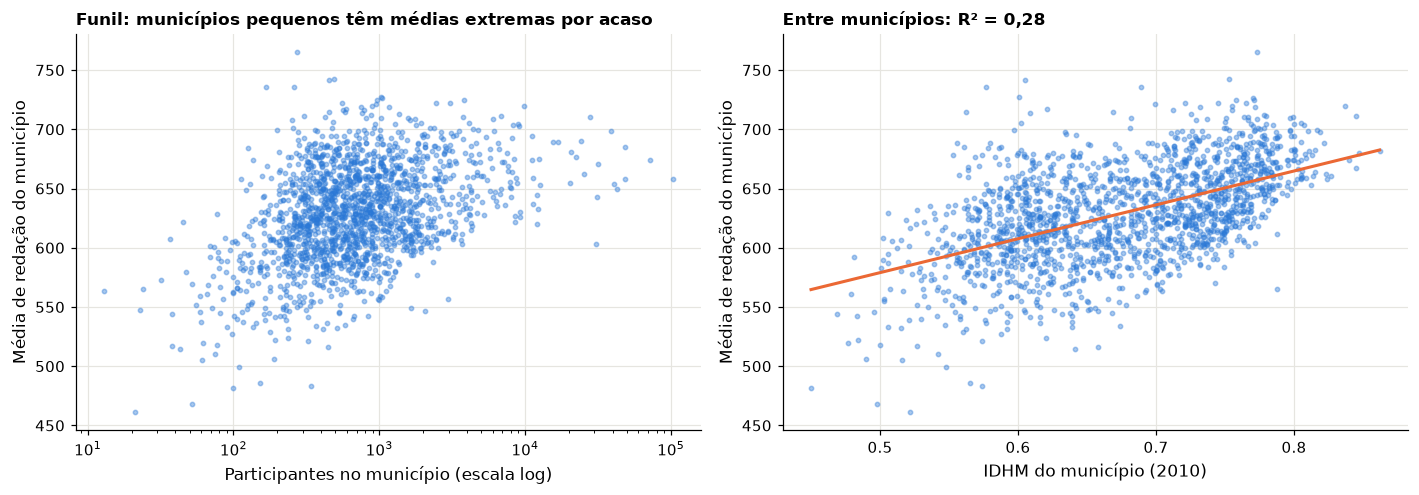

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.scatter(mun.n, mun.NU_NOTA_REDACAO, s=8, alpha=0.4, color=AZUL)
ax.set_xscale('log')
ax.set_xlabel('Participantes no município (escala log)'); ax.set_ylabel('Média de redação do município')
ax.set_title('Funil: municípios pequenos têm médias extremas por acaso', fontsize=11)
ax = axes[1]
ax.scatter(mun.idhm, mun.NU_NOTA_REDACAO, s=8, alpha=0.4, color=AZUL)
m_eco = sm.OLS(mun.NU_NOTA_REDACAO, sm.add_constant(mun.idhm)).fit()
xs = np.linspace(mun.idhm.min(), mun.idhm.max(), 50)
ax.plot(xs, m_eco.params['const'] + m_eco.params['idhm'] * xs, color=LARANJA, lw=2)
ax.set_xlabel('IDHM do município (2010)'); ax.set_ylabel('Média de redação do município')
ax.set_title(f'Entre municípios: R² = {br(m_eco.rsquared, 2)}', fontsize=11)
plt.tight_layout()
salvar(fig, 'm6_idhm_funil_dispersao')
plt.show()

In [69]:
# A mesma relação no nível do ALUNO: cada participante recebe o IDHM do município da prova
ind = base[['CO_MUNICIPIO_PROVA', 'NU_NOTA_REDACAO']].merge(idhm[['id_municipio', 'idhm']], left_on='CO_MUNICIPIO_PROVA',
                                                             right_on='id_municipio', how='inner')
m_ind = sm.OLS(ind.NU_NOTA_REDACAO, sm.add_constant(ind.idhm)).fit()
m_eco_pond = sm.WLS(mun.NU_NOTA_REDACAO, sm.add_constant(mun.idhm), weights=mun.n).fit()
pd.DataFrame({
    'inclinação (pontos por 0,1 de IDHM)': [m_eco.params['idhm'] / 10, m_eco_pond.params['idhm'] / 10, m_ind.params['idhm'] / 10],
    'R²': [m_eco.rsquared, m_eco_pond.rsquared, m_ind.rsquared],
    'n': [len(mun), len(mun), len(ind)],
}, index=['municípios (sem peso)', 'municípios (peso = nº de participantes)', 'participantes (nível individual)']).round(3)

,"inclinação (pontos por 0,1 de IDHM)",R²,n
municípios (sem peso),28.601,0.281,1750
municípios (peso = nº de participantes),28.066,0.344,1750
participantes (nível individual),28.066,0.013,2569190


**Falácia ecológica:** a inclinação é parecida nos três níveis, mas o **R² entre municípios é muito maior** que o R² entre alunos. Médias "apagam" a variação dentro de cada município. "O IDHM explica X% da nota" vale para médias municipais, **não** para alunos.

In [70]:
# A regressão múltipla das turmas anteriores, refeita com os dados de 2023
X_vars = ['idhm_e', 'idhm_l', 'idhm_r', 'indice_frequencia_escolar', 'NU_NOTA_LC', 'NU_NOTA_MT']
m_mult = sm.OLS(mun.NU_NOTA_REDACAO, sm.add_constant(mun[X_vars])).fit()
vif = [variance_inflation_factor(sm.add_constant(mun[X_vars]).to_numpy(), i + 1) for i in range(len(X_vars))]
display(pd.DataFrame({'coeficiente': m_mult.params[X_vars], 'IC95% inf': m_mult.conf_int().loc[X_vars, 0],
                      'IC95% sup': m_mult.conf_int().loc[X_vars, 1], 'VIF': vif}).round(2))
print(f'R² ajustado = {br(m_mult.rsquared_adj, 3)}')
print(f'r entre os componentes do IDHM: idhm_e × idhm_r = {br(mun.idhm_e.corr(mun.idhm_r), 2)}; idhm_l × idhm_r = {br(mun.idhm_l.corr(mun.idhm_r), 2)}')

,coeficiente,IC95% inf,IC95% sup,VIF
idhm_e,-6.61,-51.58,38.36,17.25
idhm_l,-193.79,-241.15,-146.43,3.84
idhm_r,-47.62,-82.53,-12.70,7.74
indice_frequencia_escolar,27.81,-10.96,66.58,11.25
NU_NOTA_LC,-0.91,-1.09,-0.73,15.75
NU_NOTA_MT,1.46,1.36,1.55,14.35


R² ajustado = 0,694
r entre os componentes do IDHM: idhm_e × idhm_r = 0,86; idhm_l × idhm_r = 0,85


**Por que este modelo engana:**
- O R² alto vem quase todo das **notas de LC e MT** como preditoras da redação: notas explicam notas (o mesmo desempenho medido de outra forma). Não diz nada sobre fatores socioeconômicos.
- As preditoras são **muito correlacionadas** entre si (VIF acima de 10 para IDHM-Educação, frequência escolar, LC e MT). Com elas juntas, os coeficientes ficam instáveis e trocam de sinal: o IDHM-Longevidade, o IDHM-Renda e até a nota de LC aparecem com coeficiente **negativo**. Isso **não** quer dizer que municípios com mais longevidade ou renda "pioram" a redação; é efeito da colinearidade.
- **Frase antiga:** *"As variáveis nessa equação explicam cerca de 70% do valor da nota."* **Frase correta:** *"Entre os municípios de prova, o modelo está associado a cerca de 70% da variação da média municipal de redação; o resultado se apoia sobretudo nas médias de LC e MT do próprio município e não permite conclusões sobre alunos nem sobre causas."*

### IA — Prompts do Módulo 6

**Prompt 1 — especificar o modelo e o diagnóstico (antes de rodar)**
```text
Pergunta: quanto da variação da nota de Matemática (NU_NOTA_MT) está associada à faixa de renda
familiar (Q006, ordinal A–Q) e ao tipo de escola (TP_ESCOLA: 2 pública, 3 privada), nos
concluintes de 2023? Delineamento observacional.

Tarefa:
1) Proponha um modelo de regressão linear e justifique a codificação de Q006
   (código ordinal, indicadoras ou escala log da renda), explicando o que cada escolha implica.
2) Escreva o código Python (statsmodels) com semente fixa para ajustar o modelo,
   reportar coeficientes com IC95%, R² e erro padrão residual.
3) Inclua o diagnóstico: gráfico de resíduos × ajustados, QQ-plot dos resíduos,
   variância dos resíduos por faixa dos valores ajustados.
4) Liste as limitações de interpretação causal e as variáveis omitidas prováveis.
Não conclua nada; apenas gere o código e a lista de verificações.
```

**Prompt 2 — ler um gráfico de resíduos**
```text
Descrevo o gráfico de resíduos: [padrão em U / funil / pontos isolados].
Diga: (a) qual suposição está violada, (b) qual a consequência para IC e testes,
(c) duas correções possíveis com vantagens e riscos, (d) como saber se a correção funcionou.
Não presuma informações que não descrevi.
```

**Prompt 3 — auditoria de linguagem causal e de unidade de análise**
```text
Analise o parágrafo abaixo de um relatório. Marque cada frase que sugere causa (palavras como
"efeito", "impacto", "provoca", "explica", "devido a") e diga se o delineamento descrito
(observacional/experimental) sustenta a causa. Verifique também se a conclusão fala de
indivíduos quando os dados são médias de grupos (falácia ecológica).
Reescreva as frases com linguagem de associação.
[colar parágrafo — por exemplo: "As variáveis nessa equação explicam cerca de 70% do valor
da nota de redação; o IDHM-Longevidade tem efeito negativo sobre o desempenho dos alunos."]
```

**Prompt 4 — treino/teste**
```text
Escreva código com scikit-learn para: (1) separar 70% treino e 30% teste com semente fixa;
(2) ajustar uma regressão linear apenas no treino; (3) avaliar RMSE e R² no teste;
(4) comparar com um modelo de referência que sempre prevê a média do treino.
Explique por que NÃO devo escolher variáveis ou ajustar hiperparâmetros olhando o conjunto de teste
(vazamento de dados) e como a validação cruzada k-fold resolve isso.
```

**Verificações já feitas acima:** b = r·s_y/s_x (5.2); gráfico de resíduos (5.2); RMSE contra "sempre a média" (5.5); nível de análise e VIF (5.6).

---
# Encerramento: checklist de relatório

Para cada resultado levado à diretoria:
1. **Pergunta e hipótese** escritas antes da análise (pré-registro).
2. **População** analisada e quem ficou de fora (nulos, zeros, filtros, presença).
3. **Plano amostral** e justificativa do n (precisão ou menor efeito relevante).
4. **Efeito + IC95% + valor-p + tamanho do efeito** (nunca só o valor-p).
5. **Leitura de relevância** com a margem definida antes (diferente e relevante / irrelevante / inconclusivo).
6. **Limitações:** delineamento observacional, confundidores, unidade de análise.
7. **Registro de IA:** prompt, modelo, data e a verificação independente feita.

In [71]:
# Modelo de registro de uso de IA (regra 7): uma linha por prompt usado na análise
registro_ia = pd.DataFrame(columns=['data', 'ferramenta/modelo', 'parte do notebook', 'prompt (resumo)',
                                    'o que foi aproveitado', 'verificação independente feita', 'resultado da verificação'])
registro_ia

,data,ferramenta/modelo,parte do notebook,prompt (resumo),o que foi aproveitado,verificação independente feita,resultado da verificação
